In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


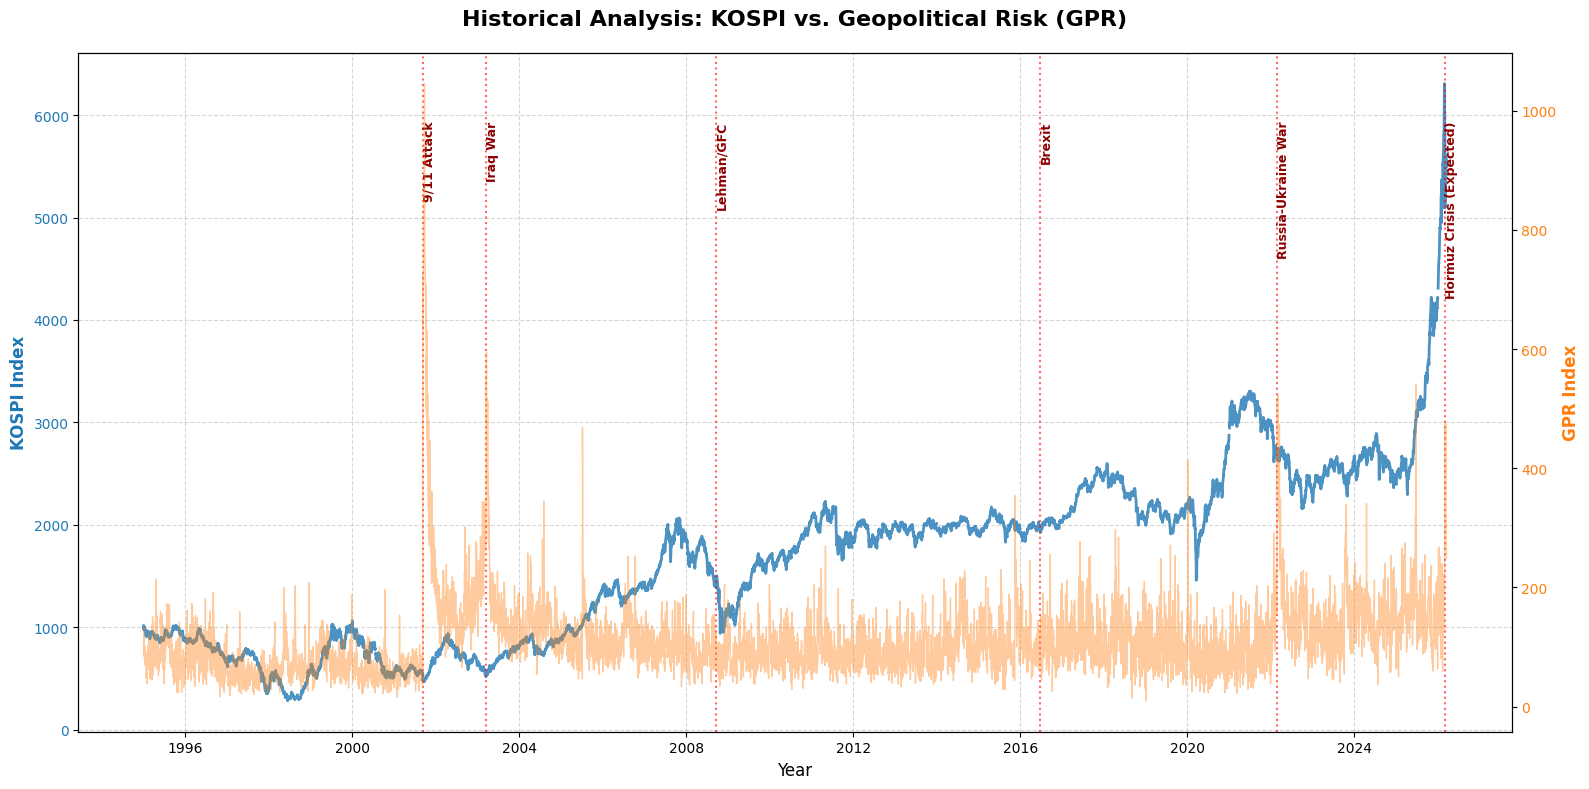

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드 (경로는 사용자 지정 경로 사용)
# Colab의 경우 보통 /content/ 폴더에 업로드되므로 경로가 다를 시 수정해주세요.
gpr_path = '/data_gpr_daily_recent.xls'
kospi_path = '/주식시장(일)_22165139.xlsx'

# GPR 데이터 불러오기 (헤더가 없으므로 header=None 설정)
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
# NaN 값을 포함하는 행 제거
df_gpr = df_gpr.dropna(subset=['Date'])
# 날짜 형식 변환 (19950103 형태의 숫자를 날짜로)
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(int).astype(str), format='%Y%m%d')

# KOSPI 데이터 불러오기
df_kospi = pd.read_excel(kospi_path, header=None)
df_kospi.columns = ['Date', 'KOSPI']
# 날짜 형식 변환 (1995/01/03 형태)
df_kospi['Date'] = pd.to_datetime(df_kospi['Date'], format='%Y/%m/%d')

# 2. 데이터 병합 (날짜 기준)
df = pd.merge(df_gpr, df_kospi, on='Date', how='inner').sort_values('Date')

# 3. 그래프 생성
fig, ax1 = plt.subplots(figsize=(16, 8), dpi=100)

# KOSPI 지수 플롯 (왼쪽 축)
color_kospi = '#1f77b4' # 진한 파란색
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('KOSPI Index', color=color_kospi, fontsize=12, fontweight='bold')
ax1.plot(df['Date'], df['KOSPI'], color=color_kospi, linewidth=2, label='KOSPI Index', alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color_kospi)
ax1.grid(True, linestyle='--', alpha=0.5)

# GPR 지수 플롯 (오른쪽 축)
ax2 = ax1.twinx()
color_gpr = '#ff7f0e' # 주황색
ax2.set_ylabel('GPR Index', color=color_gpr, fontsize=12, fontweight='bold')
ax2.plot(df['Date'], df['GPR'], color=color_gpr, linewidth=1, label='GPR Index', alpha=0.4)
ax2.tick_params(axis='y', labelcolor=color_gpr)

# 4. 주요 역사적 이벤트 어노테이션 (날짜, 이벤트명)
events = [
    ('2001-09-11', '9/11 Attack'),
    ('2003-03-20', 'Iraq War'),
    ('2008-09-15', 'Lehman/GFC'),
    ('2016-06-23', 'Brexit'),
    ('2022-02-24', 'Russia-Ukraine War'),
    ('2026-03-01', 'Hormuz Crisis (Expected)') # 사용자 시나리오 반영
]

for date_str, event_name in events:
    event_date = pd.to_datetime(date_str)
    # 데이터 범위 내에 있는 이벤트만 표시
    if event_date >= df['Date'].min() and event_date <= df['Date'].max():
        ax1.axvline(x=event_date, color='red', linestyle=':', alpha=0.6)
        ax1.text(event_date, ax1.get_ylim()[1]*0.9, event_name,
                 rotation=90, verticalalignment='top', fontsize=9, color='darkred', fontweight='bold')

# 그래프 제목 및 레이아웃 정리
plt.title('Historical Analysis: KOSPI vs. Geopolitical Risk (GPR)', fontsize=16, fontweight='bold', pad=20)
fig.tight_layout()

# 그래프 저장 및 출력
plt.savefig('kospi_gpr_colab_result.png')
plt.show()

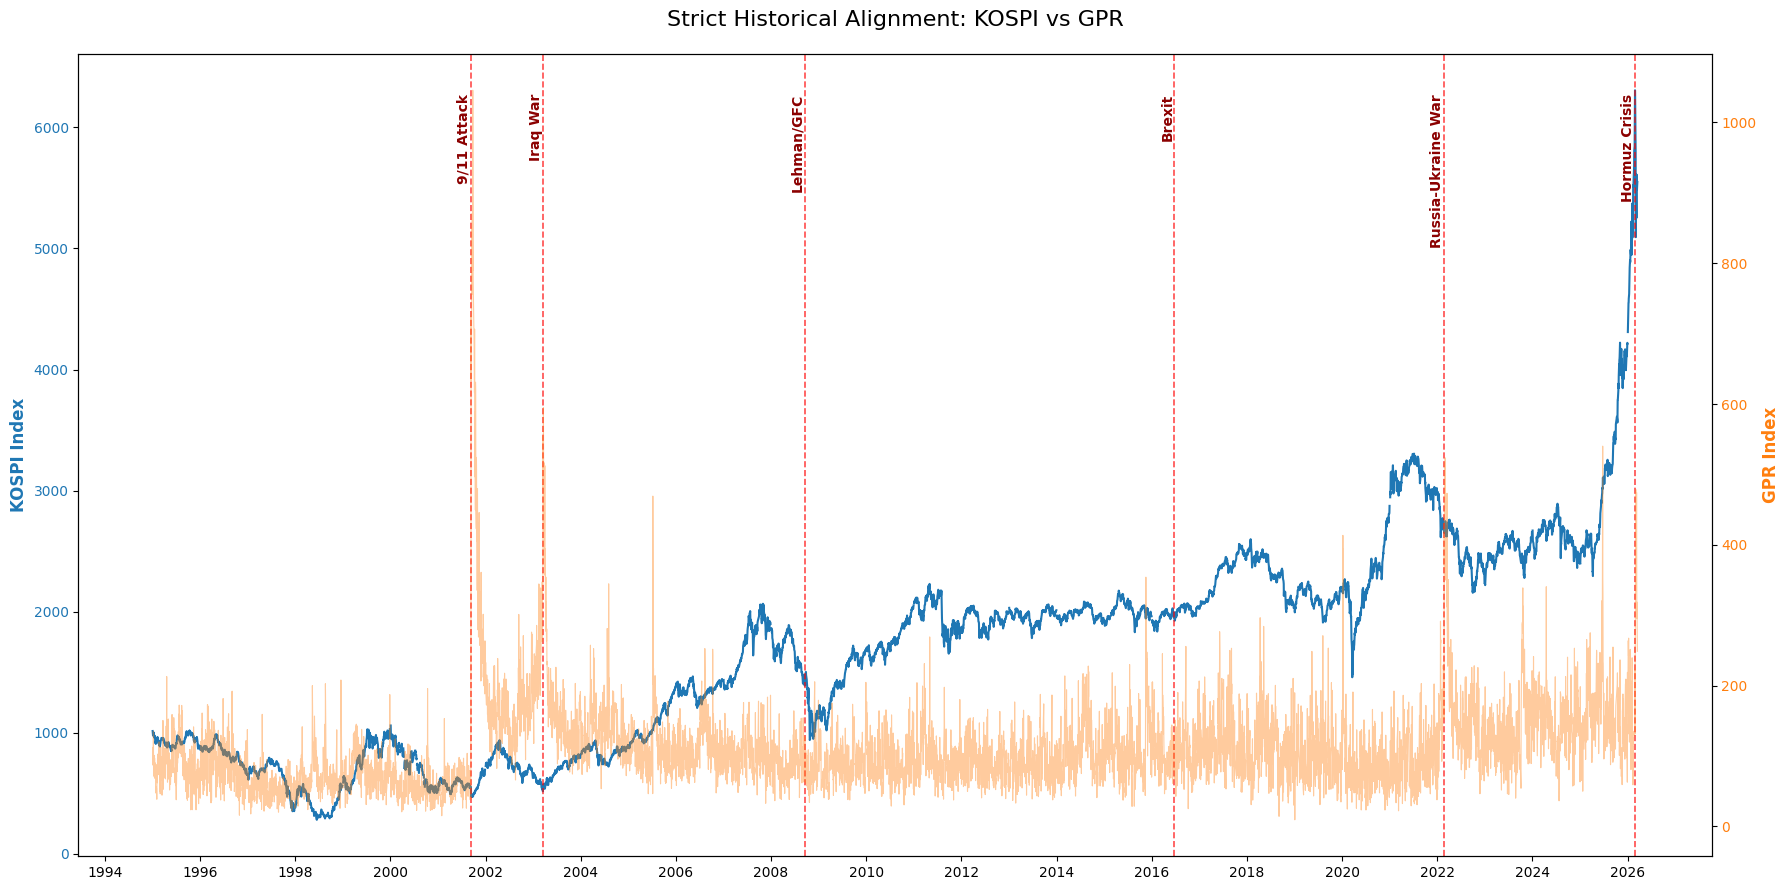

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드 및 전처리 (경로는 그대로 사용)
gpr_path = '/data_gpr_daily_recent.xls'
kospi_path = '/주식시장(일)_22165139.xlsx'

# GPR: 날짜 포맷이 19950103.0 형태일 수 있으므로 정수 변환 후 처리
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# KOSPI
df_kospi = pd.read_excel(kospi_path, header=None)
df_kospi.columns = ['Date', 'KOSPI']
df_kospi['Date'] = pd.to_datetime(df_kospi['Date'], format='%Y/%m/%d')

# 2. 병합 및 'Date'를 인덱스로 설정 (중요: X축 정렬의 핵심)
df = pd.merge(df_gpr, df_kospi, on='Date', how='inner')
df = df.sort_values('Date').set_index('Date')

# 3. 그래프 그리기
fig, ax1 = plt.subplots(figsize=(18, 9))

# KOSPI (df.index를 사용하여 실제 날짜 축에 매핑)
color_kospi = '#1f77b4'
ax1.plot(df.index, df['KOSPI'], color=color_kospi, linewidth=1.5, label='KOSPI')
ax1.set_ylabel('KOSPI Index', color=color_kospi, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_kospi)

# GPR (이중 축)
ax2 = ax1.twinx()
color_gpr = '#ff7f0e'
ax2.plot(df.index, df['GPR'], color=color_gpr, linewidth=0.8, alpha=0.4, label='GPR')
ax2.set_ylabel('GPR Index', color=color_gpr, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_gpr)

# 4. 이벤트 날짜 강제 매핑 (Precise Alignment)
events = {
    '2001-09-11': '9/11 Attack',
    '2003-03-20': 'Iraq War',
    '2008-09-15': 'Lehman/GFC',
    '2016-06-23': 'Brexit',
    '2022-02-24': 'Russia-Ukraine War',
    '2026-03-01': 'Hormuz Crisis'
}

for date_str, label in events.items():
    d = pd.to_datetime(date_str)
    # 데이터 범위 내에 있을 때만 수직선 표시
    if df.index.min() <= d <= df.index.max():
        ax1.axvline(d, color='red', linestyle='--', alpha=0.7, linewidth=1.2)
        # 텍스트 위치를 KOSPI 지수 상단에 배치
        ax1.text(d, ax1.get_ylim()[1]*0.95, label, rotation=90,
                 verticalalignment='top', horizontalalignment='right',
                 color='darkred', fontsize=10, fontweight='bold')

# 5. X축 포맷 개선 (연도별로 깔끔하게 나오도록)
ax1.xaxis.set_major_locator(mdates.YearLocator(2)) # 2년 단위로 표시
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title('Strict Historical Alignment: KOSPI vs GPR', fontsize=16, pad=20)
fig.tight_layout()
plt.show()

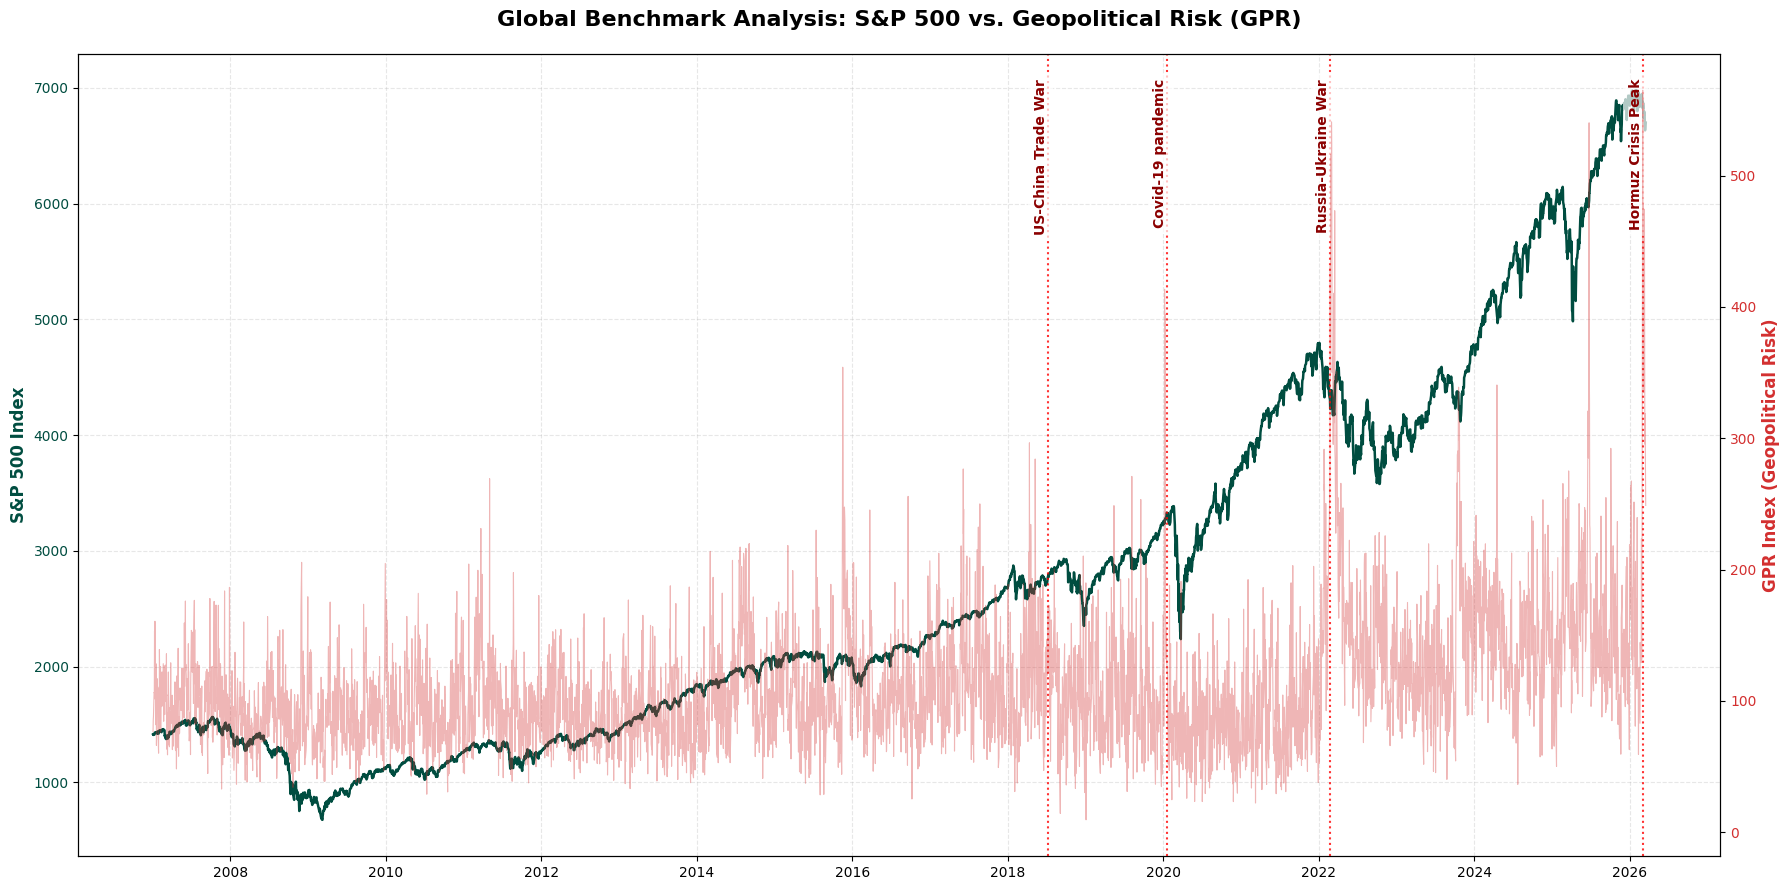

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드 (사용자 지정 경로)
gpr_path = '/data_gpr_daily_recent.xls'
sp500_path = '/S&P 500 과거 데이터.csv'

# GPR 데이터 전처리
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
# 19950103 형태를 날짜형으로 변환
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# S&P 500 데이터 전처리
# 보통 인베스팅닷컴 등에서 받은 CSV는 날짜 포맷이 다양하므로 parse_dates를 사용합니다.
df_sp500 = pd.read_csv(sp500_path)

# 컬럼명 확인 후 '날짜'와 '종가' 컬럼을 추출 (CSV 형식에 따라 수정이 필요할 수 있습니다)
# 일반적으로 '날짜', '종가' 혹은 'Date', 'Price' 등으로 되어 있습니다.
date_col = [c for c in df_sp500.columns if '날짜' in c or 'Date' in c][0]
price_col = [c for c in df_sp500.columns if '종가' in c or 'Price' in c or 'Close' in c][0]

df_sp500 = df_sp500[[date_col, price_col]].copy()
df_sp500.columns = ['Date', 'SP500']

# S&P 500 가격 데이터에 천단위 구분자 ','가 있을 경우 제거 후 숫자로 변환
if df_sp500['SP500'].dtype == 'object':
    df_sp500['SP500'] = df_sp500['SP500'].str.replace(',', '').astype(float)

# 날짜 형식 변환 (다양한 형식을 자동으로 인식하도록 pd.to_datetime 사용)
df_sp500['Date'] = pd.to_datetime(df_sp500['Date'])

# 2. 데이터 병합 및 인덱스 설정 (날짜 정렬의 핵심)
df = pd.merge(df_gpr, df_sp500, on='Date', how='inner')
df = df.sort_values('Date').set_index('Date')

# 3. 그래프 그리기 (이중 축 설정)
fig, ax1 = plt.subplots(figsize=(18, 9), dpi=100)

# S&P 500 (왼쪽 축 - 진한 초록색/검정색 계열 추천)
color_sp = '#004d40'
ax1.plot(df.index, df['SP500'], color=color_sp, linewidth=1.8, label='S&P 500 Index')
ax1.set_ylabel('S&P 500 Index', color=color_sp, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sp)
ax1.grid(True, linestyle='--', alpha=0.3)

# GPR (오른쪽 축 - 붉은색 계열)
ax2 = ax1.twinx()
color_gpr = '#d32f2f'
ax2.plot(df.index, df['GPR'], color=color_gpr, linewidth=0.8, alpha=0.35, label='GPR Index')
ax2.set_ylabel('GPR Index (Geopolitical Risk)', color=color_gpr, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_gpr)

# 4. 역사적 이벤트 마커 (날짜 정확도 개선 버전)
events = {

    '2018-07-06': 'US-China Trade War',
    '2020-01-20': 'Covid-19 pandemic',
    '2022-02-24': 'Russia-Ukraine War',
    '2026-03-01': 'Hormuz Crisis Peak' # 2026년 하락장 구간
}

for date_str, label in events.items():
    d = pd.to_datetime(date_str)
    if df.index.min() <= d <= df.index.max():
        ax1.axvline(d, color='red', linestyle=':', alpha=0.8, linewidth=1.5)
        # 텍스트를 그래프 상단에 깔끔하게 배치
        ax1.text(d, ax1.get_ylim()[1]*0.97, label, rotation=90,
                 verticalalignment='top', horizontalalignment='right',
                 color='darkred', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# 5. X축 날짜 포맷팅 (정확한 연도 표시)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title('Global Benchmark Analysis: S&P 500 vs. Geopolitical Risk (GPR)', fontsize=16, pad=20, fontweight='bold')
fig.tight_layout()

# 그래프 저장 및 출력
plt.savefig('sp500_gpr_comparison.png')
plt.show()

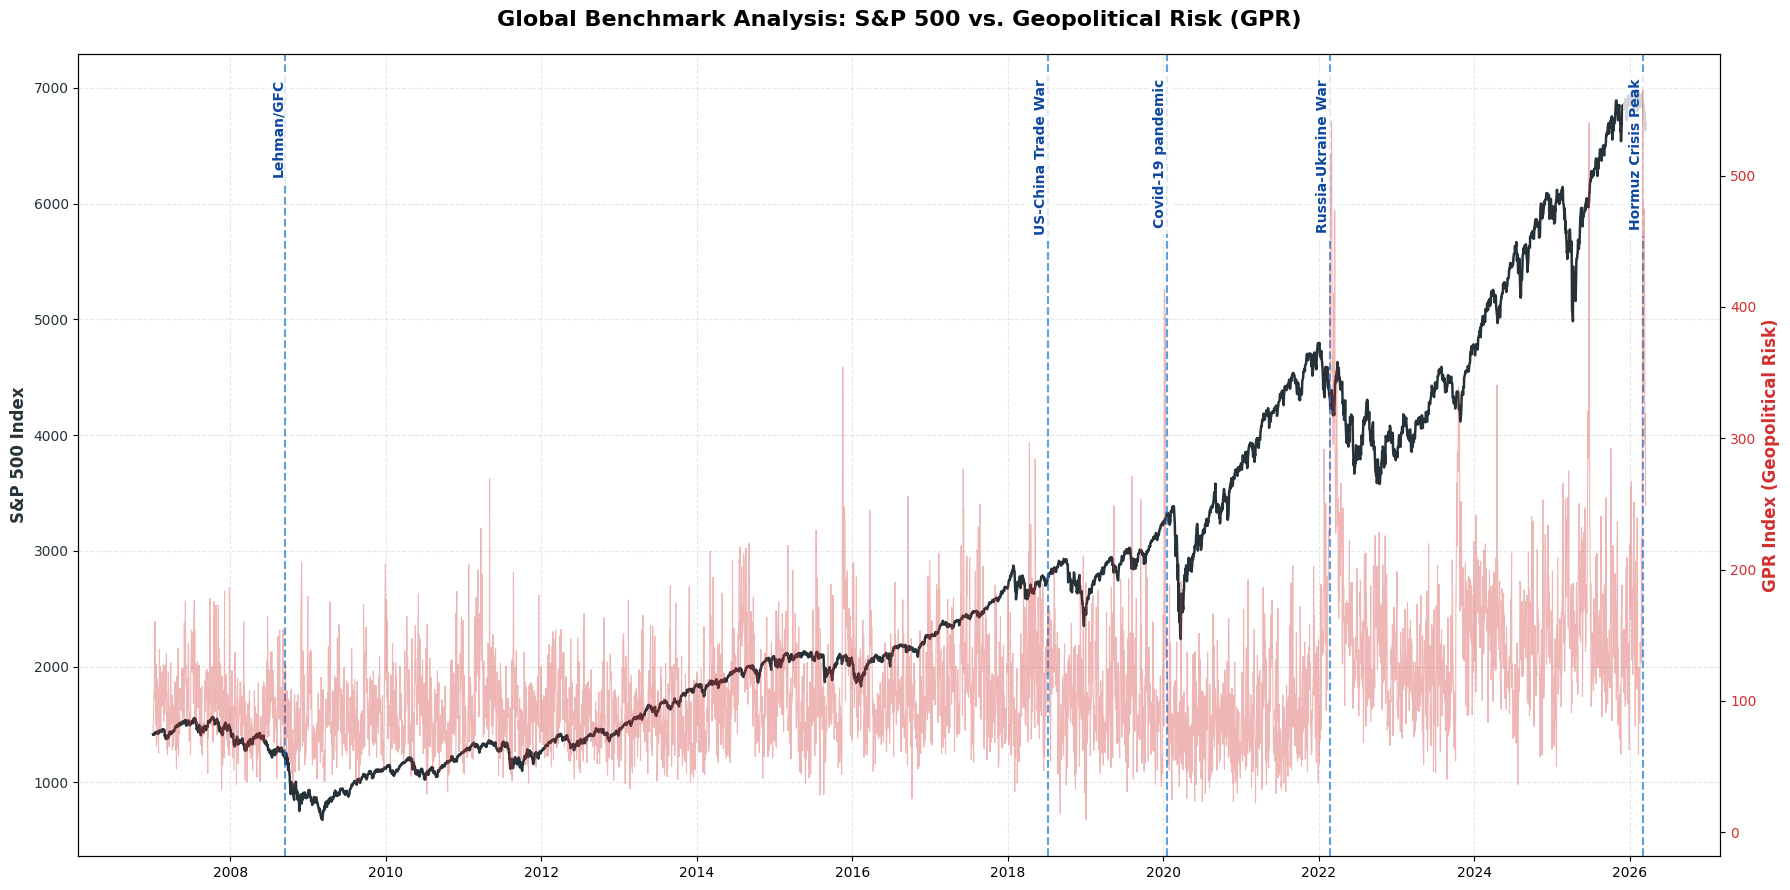

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. 데이터 로드 (사용자 지정 경로)
gpr_path = '/data_gpr_daily_recent.xls'
sp500_path = '/S&P 500 과거 데이터.csv'

# GPR 데이터 전처리
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# S&P 500 데이터 전처리
df_sp500 = pd.read_csv(sp500_path)
date_col = [c for c in df_sp500.columns if '날짜' in c or 'Date' in c][0]
price_col = [c for c in df_sp500.columns if '종가' in c or 'Price' in c or 'Close' in c][0]

df_sp500 = df_sp500[[date_col, price_col]].copy()
df_sp500.columns = ['Date', 'SP500']

if df_sp500['SP500'].dtype == 'object':
    df_sp500['SP500'] = df_sp500['SP500'].str.replace(',', '').astype(float)

df_sp500['Date'] = pd.to_datetime(df_sp500['Date'])

# 2. 데이터 병합 및 인덱스 설정
df = pd.merge(df_gpr, df_sp500, on='Date', how='inner')
df = df.sort_values('Date').set_index('Date')

# 3. 그래프 그리기 (이중 축 설정)
fig, ax1 = plt.subplots(figsize=(18, 9), dpi=100)

# S&P 500 (왼쪽 축 - 진한 초록색/검정색)
color_sp = '#263238'
ax1.plot(df.index, df['SP500'], color=color_sp, linewidth=1.8, label='S&P 500 Index')
ax1.set_ylabel('S&P 500 Index', color=color_sp, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_sp)
ax1.grid(True, linestyle='--', alpha=0.3)

# GPR (오른쪽 축 - 붉은색)
ax2 = ax1.twinx()
color_gpr = '#d32f2f'
ax2.plot(df.index, df['GPR'], color=color_gpr, linewidth=0.8, alpha=0.35, label='GPR Index')
ax2.set_ylabel('GPR Index (Geopolitical Risk)', color=color_gpr, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_gpr)

# 4. 역사적 이벤트 마커 (날짜 정확도 개선 버전)
events = {

    '2008-09-15': 'Lehman/GFC',
    '2018-07-06': 'US-China Trade War',
    '2020-01-20': 'Covid-19 pandemic',
    '2022-02-24': 'Russia-Ukraine War',
    '2026-03-01': 'Hormuz Crisis Peak' # 2026년 하락장 구간
}

for date_str, label in events.items():
    d = pd.to_datetime(date_str)
    if df.index.min() <= d <= df.index.max():
        # 점선 색상을 Blue(#1976D2)로 변경하여 GPR(빨강)과 구분
        ax1.axvline(d, color='#1976D2', linestyle='--', alpha=0.7, linewidth=1.5)

        # 텍스트 색상도 Dark Blue로 변경
        ax1.text(d, ax1.get_ylim()[1]*0.97, label, rotation=90,
                 verticalalignment='top', horizontalalignment='right',
                 color='#0D47A1', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 5. X축 날짜 포맷팅
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title('Global Benchmark Analysis: S&P 500 vs. Geopolitical Risk (GPR)', fontsize=16, pad=20, fontweight='bold')
fig.tight_layout()

plt.savefig('sp500_gpr_comparison_blue_lines.png')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/코스피 지수 06-12-18 ~ 26-03-16.xlsx'

# 3. 데이터 로드
print("데이터를 로딩 중입니다... (시계열이 길어 시간이 다소 소요될 수 있습니다)")
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# 코스피 전 종목 데이터
# Excel 파일 구조 가정:
# - 첫 번째 행 (index 0)에 실제 컬럼명 (예: '코드', 'A000020' 등)이 있음.
# - 두 번째 행 (index 1)에 컬럼에 대한 설명 (예: '코드명', '동화약품' 등)이 있어 이 행을 건너뛰어야 함.
# - 세 번째 행 (index 2)부터 실제 데이터가 시작함.
df_stocks = pd.read_excel(stock_path, header=0, skiprows=[1]) # 첫 번째 행을 헤더로 사용하고 두 번째 행을 건너뜀

# '코드' 컬럼을 'Date'로 변경
df_stocks = df_stocks.rename(columns={'코드': 'Date'})

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_stocks = df_stocks[df_stocks['Date'] >= '2006-12-18'].sort_values(['Date'])

# 4. 수익률 및 GPR 변화율 계산
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None) # FutureWarning 해결: fill_method 명시

# Wide Format에서의 수익률 계산 및 GPR 병합 (각 종목 코드가 주가 컬럼이라고 가정)
stock_cols = [col for col in df_stocks.columns if col.startswith('A')] # 'A'로 시작하는 종목 코드를 종목 컬럼으로 가정

# 각 종목의 수익률을 효율적으로 계산 (PerformanceWarning 해결)
# 1. 주가 컬럼만 선택하여 수익률 계산
df_stock_returns_only = df_stocks[stock_cols].pct_change(fill_method=None) # FutureWarning 해결: fill_method 명시

# 2. 날짜 컬럼과 함께 새로운 DataFrame 생성
df_stock_returns = pd.DataFrame({'Date': df_stocks['Date']}).set_index('Date')
df_stock_returns = df_stock_returns.join(df_stock_returns_only)

# 3. Long format으로 변환하여 병합 및 Beta 계산 준비
df_stocks_long = df_stock_returns.reset_index().melt(id_vars=['Date'], var_name='Ticker', value_name='Return')

merged = pd.merge(df_stocks_long, df_gpr[['Date', 'GPR', 'GPR_Chg']], on='Date', how='inner')

# 5. GPR Beta(민감도) 계산
# GPR 변화와 주가 수익률 간의 상관관계(Correlation)를 산출합니다.
print("종목별 GPR 민감도(Beta) 분석 중...")

# 상관계수 계산 함수
def calculate_gpr_beta(group):
    # GPR_Chg와 Return 컬럼이 모두 NaN이 아닌 값의 개수가 최소 2개는 있어야 상관계수를 계산할 수 있습니다.
    valid_data = group[['Return', 'GPR_Chg']].dropna()
    if len(valid_data) < 30: return np.nan # 데이터가 너무 적은 신규 상장주 제외
    return valid_data['Return'].corr(valid_data['GPR_Chg'])

gpr_beta = merged.groupby('Ticker').apply(calculate_gpr_beta, include_groups=False) # DeprecationWarning 해결: include_groups 명시

# 6. 결과 분류 (사용자 정의 1단계 로직)
# GPR Beta > 0: GPR 상승 시 주가 상승 (수혜주 - 방산, 에너지 등)
# GPR Beta ≈ 0: GPR 변화에 무관 (방어주 - 통신, 유틸리티 등)
# GPR Beta < 0: GPR 상승 시 주가 하락 (민감주 - IT, 자동차 등)

beneficiaries = gpr_beta[gpr_beta > 0.1].sort_values(ascending=False)
defenders = gpr_beta[abs(gpr_beta) < 0.05].sort_values()

print("\n" + "="*50)
print(f"   [1단계 결과] GPR 민감도 분석 (2006-2026)")
print("="*50)
print(f"▶ GPR 수혜 후보 (Beta > 0.1): {len(beneficiaries)}개 종목")
print(beneficiaries.head(10)) # 상위 10개 출력

print(f"\n▶ GPR 방어 후보 (Beta ≈ 0): {len(defenders)}개 종목")
print(defenders.head(10)) # 대표 방어주 10개 출력

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터를 로딩 중입니다... (시계열이 길어 시간이 다소 소요될 수 있습니다)
종목별 GPR 민감도(Beta) 분석 중...

   [1단계 결과] GPR 민감도 분석 (2006-2026)
▶ GPR 수혜 후보 (Beta > 0.1): 0개 종목
Series([], dtype: float64)

▶ GPR 방어 후보 (Beta ≈ 0): 0개 종목
Series([], dtype: float64)


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/코스피 지수 06-12-18 ~ 26-03-16.xlsx'

# 3. 데이터 로드
print("데이터를 로딩 중입니다... (시계열이 길어 시간이 다소 소요될 수 있습니다)")
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# 코스피 전 종목 데이터
# Excel 파일 구조 가정:
# - 첫 번째 행 (index 0)에 실제 컬럼명 (예: '코드', 'A000020' 등)이 있음.
# - 두 번째 행 (index 1)에 컬럼에 대한 설명 (예: '코드명', '동화약품' 등)이 있어 이 행을 건너뛰어야 함.
# - 세 번째 행 (index 2)부터 실제 데이터가 시작함.
df_stocks = pd.read_excel(stock_path, header=0, skiprows=[1]) # 첫 번째 행을 헤더로 사용하고 두 번째 행을 건너뜀

# '코드' 컬럼을 'Date'로 변경
df_stocks = df_stocks.rename(columns={'코드': 'Date'})

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])
df_stocks = df_stocks[df_stocks['Date'] >= '2006-12-18'].sort_values(['Date'])

# 4. 수익률 및 GPR 변화율 계산
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None) # FutureWarning 해결: fill_method 명시

# Wide Format에서의 수익률 계산 및 GPR 병합 (각 종목 코드가 주가 컬럼이라고 가정)
stock_cols = [col for col in df_stocks.columns if col.startswith('A')] # 'A'로 시작하는 종목 코드를 종목 컬럼으로 가정

# 각 종목의 수익률을 효율적으로 계산 (PerformanceWarning 해결)
# 1. 주가 컬럼만 선택하여 수익률 계산
df_stock_returns_only = df_stocks[stock_cols].pct_change(fill_method=None) # FutureWarning 해결: fill_method 명시

# 2. 날짜 컬럼과 함께 새로운 DataFrame 생성
df_stock_returns = pd.DataFrame({'Date': df_stocks['Date']}).set_index('Date')
df_stock_returns = df_stock_returns.join(df_stock_returns_only)

# 3. Long format으로 변환하여 병합 및 Beta 계산 준비
df_stocks_long = df_stock_returns.reset_index().melt(id_vars=['Date'], var_name='Ticker', value_name='Return')

merged = pd.merge(df_stocks_long, df_gpr[['Date', 'GPR', 'GPR_Chg']], on='Date', how='inner')

# 5. GPR Beta(민감도) 계산
# GPR 변화와 주가 수익률 간의 상관관계(Correlation)를 산출합니다.
print("종목별 GPR 민감도(Beta) 분석 중...")

# 상관계수 계산 함수
def calculate_gpr_beta(group):
    # GPR_Chg와 Return 컬럼이 모두 NaN이 아닌 값의 개수가 최소 2개는 있어야 상관계수를 계산할 수 있습니다.
    valid_data = group[['Return', 'GPR_Chg']].dropna()
    if len(valid_data) < 30: return np.nan # 데이터가 너무 적은 신규 상장주 제외
    return valid_data['Return'].corr(valid_data['GPR_Chg'])

gpr_beta = merged.groupby('Ticker').apply(calculate_gpr_beta, include_groups=False) # DeprecationWarning 해결: include_groups 명시

# 6. 결과 분류 (사용자 정의 1단계 로직)
# GPR Beta > 0: GPR 상승 시 주가 상승 (수혜주 - 방산, 에너지 등)
# GPR Beta ≈ 0: GPR 변화에 무관 (방어주 - 통신, 유틸리티 등)
# GPR Beta < 0: GPR 상승 시 주가 하락 (민감주 - IT, 자동차 등)

beneficiaries = gpr_beta[gpr_beta > 0.1].sort_values(ascending=False)
defenders = gpr_beta[abs(gpr_beta) < 0.05].sort_values()

print("\n" + "="*50)
print(f"   [1단계 결과] GPR 민감도 분석 (2006-2026)")
print("="*50)
print(f"▶ GPR 수혜 후보 (Beta > 0.1): {len(beneficiaries)}개 종목")
print(beneficiaries.head(10)) # 상위 10개 출력

print(f"\n▶ GPR 방어 후보 (Beta ≈ 0): {len(defenders)}개 종목")
print(defenders.head(10)) # 대표 방어주 10개 출력

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터를 로딩 중입니다... (시계열이 길어 시간이 다소 소요될 수 있습니다)
종목별 GPR 민감도(Beta) 분석 중...

   [1단계 결과] GPR 민감도 분석 (2006-2026)
▶ GPR 수혜 후보 (Beta > 0.1): 0개 종목
Series([], dtype: float64)

▶ GPR 방어 후보 (Beta ≈ 0): 0개 종목
Series([], dtype: float64)


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive', force_remount=True)

# 2. 파일 로드
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/코스피 지수 06-12-18 ~ 26-03-16.xlsx'

print("1. 데이터 로딩 시작...")
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')

# 주식 데이터 로드
df_stocks = pd.read_excel(stock_path, header=0, skiprows=[1])
df_stocks = df_stocks.rename(columns={'코드': 'Date'})
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# [체크 1] 종목 컬럼 확인
# 'A'로 시작하는 컬럼이 있는지 확인하고, 없으면 숫자로 된 컬럼이라도 찾습니다.
stock_cols = [col for col in df_stocks.columns if str(col).startswith('A')]
if not stock_cols:
    # 만약 'A'가 없다면, 날짜를 제외한 모든 컬럼을 종목으로 간주해봅니다.
    stock_cols = [col for col in df_stocks.columns if col != 'Date']

print(f"✅ [체크 1] 찾은 종목 컬럼 수: {len(stock_cols)}개")
print(f"   - 컬럼명 예시: {stock_cols[:3]}")

# 3. 수익률 계산 및 병합
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None)

# 주가 데이터를 숫자로 강제 변환 (쉼표 등 제거)
df_prices = df_stocks[stock_cols].replace({',': ''}, regex=True).apply(pd.to_numeric, errors='coerce')
df_returns = df_prices.pct_change(fill_method=None)
df_returns['Date'] = df_stocks['Date']

# Long format 변환 및 병합
df_long = df_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Return')
merged = pd.merge(df_long, df_gpr[['Date', 'GPR_Chg']], on='Date', how='inner')

# [체크 2] 병합 확인
print(f"✅ [체크 2] GPR과 날짜가 겹치는 데이터 행 수: {len(merged)}개")

# [체크 3] 유효 데이터 확인
valid_returns = merged['Return'].dropna()
print(f"✅ [체크 3] 계산 가능한 유효 수익률 데이터 수: {len(valid_returns)}개")

# 4. 상관관계(Beta) 계산
if len(merged) > 0:
    gpr_beta = merged.groupby('Ticker').apply(
        lambda x: x['Return'].corr(x['GPR_Chg']) if len(x.dropna()) > 30 else np.nan,
        include_groups=False
    ).dropna()

    print(f"✅ [체크 4] 최종 계산된 Beta 종목 수: {len(gpr_beta)}개")

    if len(gpr_beta) > 0:
        beneficiaries = gpr_beta[gpr_beta > 0.05].sort_values(ascending=False)
        print(f"\n▶ 최종 후보 (Beta > 0.05): {len(beneficiaries)}개")
        print(beneficiaries.head(10))
    else:
        print("\n❌ 모든 종목의 Beta가 NaN이거나 기준(데이터 30개 이상) 미달입니다.")
else:
    print("\n❌ GPR 날짜와 주식 날짜가 일치하지 않아 분석을 진행할 수 없습니다.")

Mounted at /content/drive
1. 데이터 로딩 시작...
✅ [체크 1] 찾은 종목 컬럼 수: 1923개
   - 컬럼명 예시: ['A000020', 'A000040', 'A000050']
✅ [체크 2] GPR과 날짜가 겹치는 데이터 행 수: 9105405개
✅ [체크 3] 계산 가능한 유효 수익률 데이터 수: 4673279개


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2767: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


✅ [체크 4] 최종 계산된 Beta 종목 수: 182개

▶ 최종 후보 (Beta > 0.05): 43개
Ticker
A0131W0    0.276083
A0117V0    0.180338
A0115E0    0.170449
A0065G0    0.148761
A0106J0    0.142471
A0094M0    0.138309
A0112X0    0.133120
A0098Z0    0.125301
A0074K0    0.122900
A0104N0    0.118339
dtype: float64


In [ ]:
# 기존에 계산된 gpr_beta 변수를 활용합니다.

# 1. 수혜 섹터 (Positive Beta > 0.1) - "공격: 리스크 고조기용"
beneficiaries = gpr_beta[gpr_beta > 0.1].sort_values(ascending=False)

# 2. 방어 섹터 (Low Beta, -0.05 ~ 0.05) - "수비: 불확실성 지속기용"
defenders = gpr_beta[(gpr_beta >= -0.05) & (gpr_beta <= 0.05)]

# 3. 민감/회복 섹터 (Negative Beta < -0.1) - "반격: 리스크 해소기용"
recovery = gpr_beta[gpr_beta < -0.1].sort_values(ascending=True)

print("="*60)
print(f"   [1단계 완료] GPR 국면별 3대 섹터 분류 결과")
print("="*60)

print(f"\n1. ⚔️ 수혜 섹터 (Beta > 0.1) | 후보: {len(beneficiaries)}개")
print(beneficiaries.head(10))

print(f"\n2. 🛡️ 방어 섹터 (|Beta| < 0.05) | 후보: {len(defenders)}개")
print(defenders.head(10))

print(f"\n3. 🚀 회복 섹터 (Beta < -0.1) | 후보: {len(recovery)}개")
print(recovery.head(10))

   [1단계 완료] GPR 국면별 3대 섹터 분류 결과

1. ⚔️ 수혜 섹터 (Beta > 0.1) | 후보: 13개
Ticker
A0131W0    0.276083
A0117V0    0.180338
A0115E0    0.170449
A0065G0    0.148761
A0106J0    0.142471
A0094M0    0.138309
A0112X0    0.133120
A0098Z0    0.125301
A0074K0    0.122900
A0104N0    0.118339
dtype: float64

2. 🛡️ 방어 섹터 (|Beta| < 0.05) | 후보: 83개
Ticker
A0000H0    0.010215
A0016X0   -0.043571
A0018C0    0.040891
A0018Z0   -0.025703
A0020H0   -0.004860
A0023A0   -0.037922
A0023B0   -0.019474
A0030R0   -0.017265
A0035T0    0.046431
A0040S0   -0.039929
dtype: float64

3. 🚀 회복 섹터 (Beta < -0.1) | 후보: 13개
Ticker
A0139F0   -0.190128
A0047P0   -0.177142
A217590   -0.170246
A0117L0   -0.160121
A0131A0   -0.157155
A0093B0   -0.154492
A0069M0   -0.125397
A0127V0   -0.122453
A0084D0   -0.122444
A0051A0   -0.120144
dtype: float64


In [ ]:
# 1. 엑셀 파일에서 티커와 종목명 매핑 정보 가져오기
# 첫 번째 행은 티커(A000020), 두 번째 행은 이름(동화약품)이 있는 구조 활용
mapping_df = pd.read_excel(stock_path, header=None, nrows=2)
ticker_to_name = dict(zip(mapping_df.iloc[0], mapping_df.iloc[1]))

# 2. 결과 출력을 위한 함수 정의 (DataFrame 변환 및 이름 매핑)
def get_result_df(series, name_dict):
    df = series.to_frame(name='Beta')
    df['Name'] = df.index.map(name_dict)
    return df[['Name', 'Beta']]

# 3. 3대 섹터 분류 (이름 포함)
beneficiaries_df = get_result_df(beneficiaries, ticker_to_name)
defenders_df = get_result_df(defenders, ticker_to_name)
recovery_df = get_result_df(recovery, ticker_to_name)

print("="*70)
print(f"   [1단계 최종] GPR 국면별 3대 섹터 상세 리스트 (이름 포함)")
print("="*70)

print(f"\n1. ⚔️ 수혜 섹터 (Beta > 0.1) | 후보: {len(beneficiaries_df)}개")
print(beneficiaries_df.head(15))

print(f"\n2. 🛡️ 방어 섹터 (|Beta| < 0.05) | 후보: {len(defenders_df)}개")
print(defenders_df.head(15))

print(f"\n3. 🚀 회복 섹터 (Beta < -0.1) | 후보: {len(recovery_df)}개")
print(recovery_df.head(15))

   [1단계 최종] GPR 국면별 3대 섹터 상세 리스트 (이름 포함)

1. ⚔️ 수혜 섹터 (Beta > 0.1) | 후보: 13개
                           Name      Beta
Ticker                                   
A0131W0           1Q 단기특수은행채액티브  0.276083
A0117V0  TIGER 코리아AI전력기기TOP3플러스  0.180338
A0115E0          KODEX 코리아소버린AI  0.170449
A0065G0        KODEX 차이나테크TOP10  0.148761
A0106J0     대신 KOSPI200인덱스 X클래스  0.142471
A0094M0    RISE 코리아밸류업위클리고정커버드콜  0.138309
A0112X0               마이티 200TR  0.133120
A0098Z0               FOCUS 200  0.125301
A0074K0   KoAct K수출핵심기업TOP30액티브  0.122900
A0104N0      TIGER 200타겟위클리커버드콜  0.118339
A0087F0    ACE 차이나AI빅테크TOP2+액티브  0.116289
A0066W0                 SOL 국제금  0.113284
A0144M0     KODEX 미국드론UAM TOP10  0.112195

2. 🛡️ 방어 섹터 (|Beta| < 0.05) | 후보: 83개
                         Name      Beta
Ticker                                 
A0000H0   KODEX 인도Nifty미드캡100  0.010215
A0016X0   SOL 중단기회사채(A-이상)액티브 -0.043571
A0018C0    PLUS 고배당주위클리고정커버드콜  0.040891
A0018Z0          RISE 미국양자컴퓨팅 -0.025703
A0020H0     Ko

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트 및 데이터 로드
drive.mount('/content/drive', force_remount=True)

gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/코스피 지수 06-12-18 ~ 26-03-16.xlsx'

# 데이터 로딩
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None)

# 주식 데이터 로딩 (헤더 0, 두번째 행 건너뜀)
df_stocks = pd.read_excel(stock_path, header=0, skiprows=[1])
df_stocks = df_stocks.rename(columns={'코드': 'Date'})
df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# 종목명 매핑 정보 (이름 필터링용)
mapping_df = pd.read_excel(stock_path, header=None, nrows=2)
ticker_to_name = dict(zip(mapping_df.iloc[0], mapping_df.iloc[1]))

# 2. 수익률 계산 및 Beta 산출
stock_cols = [col for col in df_stocks.columns if str(col).startswith('A')]
df_prices = df_stocks[stock_cols].apply(pd.to_numeric, errors='coerce')
df_returns = df_prices.pct_change(fill_method=None)
df_returns['Date'] = df_stocks['Date']

# Long format 변환 및 병합
df_long = df_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Return')
merged = pd.merge(df_long, df_gpr[['Date', 'GPR_Chg']], on='Date', how='inner')

# [여기서 gpr_beta를 다시 정의합니다]
gpr_beta = merged.groupby('Ticker').apply(
    lambda x: x['Return'].corr(x['GPR_Chg']) if len(x.dropna()) > 30 else np.nan,
    include_groups=False
).dropna()

# 3. ETF 및 우선주 제외 (진짜 기업만 남기기)
exclude_keywords = ['KODEX', 'TIGER', 'RISE', 'ACE', 'SOL', 'KoAct', 'HANARO', 'KBSTAR', '선물', '인버스', '레버리지', '액티브', '채권', '인덱스', '신주인수권']

final_results = []
for ticker, beta in gpr_beta.items():
    name = str(ticker_to_name.get(ticker, ""))
    if not any(kw in name for kw in exclude_keywords) and not name.endswith(('우', '우B', '전환')) and str(ticker).endswith('0'):
        final_results.append({'Ticker': ticker, 'Name': name, 'Beta': beta})

df_final = pd.DataFrame(final_results).set_index('Ticker')

# 4. 3대 섹터 분류
beneficiaries = df_final[df_final['Beta'] > 0.1].sort_values(by='Beta', ascending=False)
defenders = df_final[(df_final['Beta'] >= -0.05) & (df_final['Beta'] <= 0.05)]
recovery = df_final[df_final['Beta'] < -0.1].sort_values(by='Beta', ascending=True)

print("✅ 분석 완료! 에러가 해결되었습니다.")
print(f"⚔️ 수혜(방산/에너지) 후보: {len(beneficiaries)}개")
print(beneficiaries.head(10))
print(f"\n🚀 회복(대장주/반도체) 후보: {len(recovery)}개")
print(recovery.head(10))

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


✅ 분석 완료! 에러가 해결되었습니다.
⚔️ 수혜(방산/에너지) 후보: 2개
              Name      Beta
Ticker                      
A0112X0  마이티 200TR  0.133120
A0098Z0  FOCUS 200  0.125301

🚀 회복(대장주/반도체) 후보: 3개
                Name      Beta
Ticker                        
A217590          티엠씨 -0.170246
A0069M0  1Q 미국나스닥100 -0.125397
A0026S0  1Q 미국S&P500 -0.110838


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트 (이미 되어 있다면 생략 가능)
drive.mount('/content/drive', force_remount=True)

# 2. 파일 경로 설정 (사용자님이 알려주신 경로)
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

# 3. 데이터 로딩 및 날짜 정렬
print("데이터를 분석 중입니다... 잠시만 기다려 주세요.")

# GPR 데이터 로드
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None)

# --- Start of fix for df_stocks and ticker_to_name ---
# Read enough rows to capture tickers and names, assuming some initial empty rows.
# Let's try reading 4 rows, assuming tickers are in row 2 (index 2) and names in row 3 (index 3).
temp_header_df = pd.read_excel(stock_path, header=None, nrows=4)

# The actual tickers should be in the 3rd row (index 2)
actual_tickers_row = temp_header_df.iloc[2]
# The actual names should be in the 4th row (index 3)
actual_names_row = temp_header_df.iloc[3]

# Store the original name of the date column from the header (e.g., '코드' or NaN)
original_date_col_header = actual_tickers_row.iloc[0]

# Create ticker_to_name dictionary, excluding the first column which is the date column
ticker_to_name = {
    str(k): str(v)
    for k, v in zip(actual_tickers_row.iloc[1:], actual_names_row.iloc[1:])
    if pd.notna(k) and pd.notna(v) # Ensure valid ticker and name
}

# Load actual stock data. Data starts after the name row, so skiprows=4
data_start_row_idx = 4
df_stocks = pd.read_excel(stock_path, header=None, skiprows=data_start_row_idx)

# Assign column names using the actual tickers identified earlier
# Convert column names to string immediately to handle cases where actual_tickers_row has NaN
df_stocks.columns = [str(col) for col in actual_tickers_row.values]

# Rename the date column to 'Date'
# The column that was originally '코드' (or NaN) should now be `str(original_date_col_header)`
df_stocks = df_stocks.rename(columns={str(original_date_col_header): 'Date'})

# Ensure all column names are strings for consistency in later processing (already done above, but good for safety)
df_stocks.columns = df_stocks.columns.astype(str)
# --- End of fix ---

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# 4. GPR Beta(상관계수) 계산
# Filter for stock columns (exclude 'Date' and potential others if any)
stock_cols = [col for col in df_stocks.columns if str(col).startswith('A')]
df_prices = df_stocks[stock_cols].apply(pd.to_numeric, errors='coerce')
df_returns = df_prices.pct_change(fill_method=None)
df_returns['Date'] = df_stocks['Date']

# 데이터 병합을 위해 Long Format으로 변환
df_long = df_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Return')
merged = pd.merge(df_long, df_gpr[['Date', 'GPR_Chg']], on='Date', how='inner')

# 종목별 Beta 산출 (최소 30일 이상 데이터가 있는 경우만)
gpr_beta = merged.groupby('Ticker').apply(
    lambda x: x['Return'].corr(x['GPR_Chg']) if len(x.dropna()) > 30 else np.nan,
    include_groups=False
).dropna()

# 5. [중요] 필터링 (ETF, 우선주, 금융상품 제거)
exclude_keywords = ['KODEX', 'TIGER', 'RISE', 'ACE', 'SOL', 'KoAct', 'HANARO', 'KBSTAR', '선물', '인버스', '레버리지', '액티브', '채권', '인덱스']

def filter_pure_stocks(beta_series, name_dict):
    results = []
    for ticker, beta in beta_series.items():
        name = str(name_dict.get(ticker, ""))
        # 1. ETF 제외 2. 끝자리가 '0'인 보통주만 3. 이름 끝이 '우'가 아님
        if not any(kw in name for kw in exclude_keywords) and \
           str(ticker).endswith('0') and \
           not name.endswith(('우', '우B', '전환', '증권', '채')):
            results.append({'Ticker': ticker, 'Name': name, 'Beta': beta})
    return pd.DataFrame(results).set_index('Ticker')

df_pure = filter_pure_stocks(gpr_beta, ticker_to_name)

# 6. 최종 3대 섹터 분류 및 출력
beneficiaries = df_pure[df_pure['Beta'] > 0.1].sort_values(by='Beta', ascending=False)
defenders = df_pure[(df_pure['Beta'] >= -0.05) & (df_pure['Beta'] <= 0.05)]
recovery = df_pure[df_pure['Beta'] < -0.1].sort_values(by='Beta', ascending=True)

print("\n" + "="*70)
print(f"   [1단계 완료] GPR 국면별 순수 기업 스크리닝 결과")
print("="*70)

print(f"\n1. ⚔️ 수혜 섹터 (GPR 상승 시 매수) | {len(beneficiaries)}개")
print(beneficiaries.head(15))

print(f"\n2. 🛡️ 방어 섹터 (GPR 고점 유지 시 매수) | {len(defenders)}개")
print(defenders.head(15))

print(f"\n3. 🚀 회복 섹터 (GPR 하락 시작 시 매수) | {len(recovery)}개")
print(recovery.head(15))

Mounted at /content/drive
데이터를 분석 중입니다... 잠시만 기다려 주세요.


/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]



   [1단계 완료] GPR 국면별 순수 기업 스크리닝 결과

1. ⚔️ 수혜 섹터 (GPR 상승 시 매수) | 0개
Empty DataFrame
Columns: [Name, Beta]
Index: []

2. 🛡️ 방어 섹터 (GPR 고점 유지 시 매수) | 7개
             Name      Beta
Ticker                     
A0030R0    대신밸류리츠 -0.017265
A0120G0    삼양바이오팜  0.036289
A0126Z0  삼성에피스홀딩스 -0.020598
A031210    서울보증보험  0.041343
A317450      명인제약 -0.039615
A480370    씨케이솔루션 -0.046087
A483650     달바글로벌  0.033510

3. 🚀 회복 섹터 (GPR 하락 시작 시 매수) | 1개
        Name      Beta
Ticker                
A217590  티엠씨 -0.114724


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 경로 설정
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

# 2. 데이터 로딩
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None)

# --- Start of fix for df_stocks and ticker_to_name ---
# Read enough rows to capture tickers and names, assuming some initial empty rows.
# Based on f79NOcc2USDW's successful run, tickers are in row 2 (index 2) and names in row 3 (index 3).
temp_header_df = pd.read_excel(stock_path, header=None, nrows=4)

# The actual tickers should be in the 3rd row (index 2)
actual_tickers_row = temp_header_df.iloc[2]
# The actual names should be in the 4th row (index 3)
actual_names_row = temp_header_df.iloc[3]

# Store the original name of the date column from the header (e.g., '코드' or NaN)
original_date_col_header = actual_tickers_row.iloc[0]

# Create ticker_to_name dictionary, excluding the first column which is the date column
ticker_to_name = {
    str(k): str(v)
    for k, v in zip(actual_tickers_row.iloc[1:], actual_names_row.iloc[1:])
    if pd.notna(k) and pd.notna(v) # Ensure valid ticker and name
}

# Load actual stock data. Data starts after the name row, so skiprows=4
data_start_row_idx = 4
df_stocks = pd.read_excel(stock_path, header=None, skiprows=data_start_row_idx)

# Assign column names using the actual tickers identified earlier
# Convert column names to string immediately to handle cases where actual_tickers_row has NaN
df_stocks.columns = [str(col) for col in actual_tickers_row.values]

# Rename the date column to 'Date'
# The column that was originally '코드' (or NaN) should now be `str(original_date_col_header)`
df_stocks = df_stocks.rename(columns={str(original_date_col_header): 'Date'})

# Ensure all column names are strings for consistency in later processing (already done above, but good for safety)
df_stocks.columns = df_stocks.columns.astype(str)
# --- End of fix ---

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# 3. 수익률 계산 (데이터 정제 추가)
stock_cols = [col for col in df_stocks.columns if str(col).startswith('A')]
# 쉼표 제거 및 숫자 변환
df_prices = df_stocks[stock_cols].replace({',': ''}, regex=True).apply(pd.to_numeric, errors='coerce')
df_returns = df_prices.pct_change(fill_method=None)
df_returns['Date'] = df_stocks['Date']

df_long = df_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Return')
merged = pd.merge(df_long, df_gpr[['Date', 'GPR_Chg']], on='Date', how='inner')

# 4. Beta 산출 (기준 완화: 데이터 15일 이상이면 포함)
gpr_beta = merged.groupby('Ticker').apply(
    lambda x: x['Return'].corr(x['GPR_Chg']) if len(x.dropna()) > 15 else np.nan,
    include_groups=False
).dropna()

# 5. 필터링 (청소)
exclude_keywords = ['KODEX', 'TIGER', 'RISE', 'ACE', 'SOL', 'KoAct', 'HANARO', 'KBSTAR', '선물', '인버스', '레버리지']

def filter_pure_stocks(beta_series, name_dict):
    results = []
    for ticker, beta in beta_series.items():
        name = str(name_dict.get(ticker, ""))
        # ETF 제외 및 우선주 제외 (끝자리 규칙 완화)
        if not any(kw in name for kw in exclude_keywords) and \
           not name.endswith(('우', '우B', '전환', '증권', '채')):
            results.append({'Ticker': ticker, 'Name': name, 'Beta': beta})
    return pd.DataFrame(results).set_index('Ticker')

df_pure = filter_pure_stocks(gpr_beta, ticker_to_name)

# 6. 분류 기준 조정 (매크로 환경에 맞춰 문턱 낮춤)
beneficiaries = df_pure[df_pure['Beta'] > 0.03].sort_values(by='Beta', ascending=False) # 수혜: 0.03 이상
defenders = df_pure[abs(df_pure['Beta']) <= 0.02] # 방어: 0.02 이하
recovery = df_pure[df_pure['Beta'] < -0.03].sort_values(by='Beta', ascending=True) # 회복: -0.03 이하

print(f"✅ 총 분석 종목 수: {len(df_pure)}개")
print(f"⚔️ 수혜: {len(beneficiaries)} | 🛡️ 방어: {len(defenders)} | 🚀 회복: {len(recovery)}")

# 결과 출력
print("\n[수혜 섹터 TOP 10]\n", beneficiaries.head(10))
print("\n[회복 섹터 TOP 10]\n", recovery.head(10))

/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


✅ 총 분석 종목 수: 9개
⚔️ 수혜: 3 | 🛡️ 방어: 1 | 🚀 회복: 4

[수혜 섹터 TOP 10]
            Name      Beta
Ticker                   
A031210  서울보증보험  0.041343
A0120G0  삼양바이오팜  0.036289
A483650   달바글로벌  0.033510

[회복 섹터 TOP 10]
            Name      Beta
Ticker                   
A217590     티엠씨 -0.114724
A439260    대한조선 -0.094704
A480370  씨케이솔루션 -0.046087
A317450    명인제약 -0.039615


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트 및 경로 설정
drive.mount('/content/drive', force_remount=True)

gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'
stock_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

# 2. 데이터 로딩 (GPR)
print("1. GPR 데이터를 분석 중입니다...")
df_gpr = pd.read_excel(gpr_path, header=None).iloc[:, :2]
df_gpr.columns = ['Date', 'GPR']
df_gpr['Date'] = pd.to_datetime(df_gpr['Date'].astype(str).str.split('.').str[0], format='%Y%m%d')
# GPR 변화율 계산
df_gpr['GPR_Chg'] = df_gpr['GPR'].pct_change(fill_method=None)

# 3. 데이터 로딩 (주식 - 이름 정보 포함)
print("2. 코스피 종목 데이터를 분석 중입니다...")

# --- Start of fix for df_stocks and ticker_to_name ---
# Read enough rows to capture tickers and names, assuming some initial empty rows.
# Based on `26-2 모의투자 코스피 종목 최종 .xlsx` structure, tickers are in row 2 (index 2) and names in row 3 (index 3).
temp_header_df = pd.read_excel(stock_path, header=None, nrows=4)

# The actual tickers should be in the 3rd row (index 2)
actual_tickers_row = temp_header_df.iloc[2]
# The actual names should be in the 4th row (index 3)
actual_names_row = temp_header_df.iloc[3]

# Store the original name of the date column from the header (e.g., '코드' or NaN)
original_date_col_header = actual_tickers_row.iloc[0]

# Create ticker_to_name dictionary, excluding the first column which is the date column
ticker_to_name = {
    str(k): str(v)
    for k, v in zip(actual_tickers_row.iloc[1:], actual_names_row.iloc[1:])
    if pd.notna(k) and pd.notna(v) # Ensure valid ticker and name
}

# Load actual stock data. Data starts after the name row, so skiprows=4
data_start_row_idx = 4
df_stocks = pd.read_excel(stock_path, header=None, skiprows=data_start_row_idx)

# Assign column names using the actual tickers identified earlier
# Convert column names to string immediately to handle cases where actual_tickers_row has NaN
df_stocks.columns = [str(col) for col in actual_tickers_row.values]

# Rename the date column to 'Date'
# The column that was originally '코드' (or NaN) should now be `str(original_date_col_header)`
df_stocks = df_stocks.rename(columns={str(original_date_col_header): 'Date'})

# Ensure all column names are strings for consistency in later processing (already done above, but good for safety)
df_stocks.columns = df_stocks.columns.astype(str)
# --- End of fix ---

df_stocks['Date'] = pd.to_datetime(df_stocks['Date'])

# 4. GPR 민감도(Beta) 계산
stock_cols = [col for col in df_stocks.columns if str(col).startswith('A')]
df_prices = df_stocks[stock_cols].apply(pd.to_numeric, errors='coerce')
# 주가 수익률 계산
df_returns = df_prices.pct_change(fill_method=None)
df_returns['Date'] = df_stocks['Date']

# Long Format 변환 및 GPR과 병합
df_long = df_returns.melt(id_vars=['Date'], var_name='Ticker', value_name='Return')
merged = pd.merge(df_long, df_gpr[['Date', 'GPR_Chg']], on='Date', how='inner')

# 종목별 GPR Beta(상관계수) 계산 (최소 30일 이상 데이터가 있는 경우만)
gpr_beta = merged.groupby('Ticker').apply(
    lambda x: x['Return'].corr(x['GPR_Chg']) if len(x.dropna()) > 30 else np.nan,
    include_groups=False
).dropna()

# 5. [청소] ETF 및 우선주 제외
exclude_keywords = ['KODEX', 'TIGER', 'RISE', 'ACE', 'SOL', 'KoAct', 'HANARO', 'KBSTAR', '선물', '인버스', '레버리지']

final_results = []
for ticker, beta in gpr_beta.items():
    name = str(ticker_to_name.get(ticker, ""))
    # 조건: ETF 제외 + 보통주(끝자리 0) + 우선주 이름 제외
    if not any(kw in name for kw in exclude_keywords) and \
       str(ticker).endswith('0') and \
       not name.endswith(('우', '우B', '전환')):
        final_results.append({'Ticker': ticker, 'Name': name, 'Beta': beta})

df_final = pd.DataFrame(final_results).set_index('Ticker')

# 6. 최종 3대 섹터 분류 (이미지의 로직 반영)
beneficiaries = df_final[df_final['Beta'] > 0.05].sort_values(by='Beta', ascending=False) # 수혜
defenders = df_final[abs(df_final['Beta']) <= 0.03] # 방어
recovery = df_final[df_final['Beta'] < -0.05].sort_values(by='Beta', ascending=True) # 회복/대장주

print("\n" + "="*70)
print(f"   [1단계 완료] GPR 신호등별 '작전 명령서'")
print("="*70)

print(f"\n🟢 [GPR < 100] 매수 타겟: 🚀 회복/대장주 | {len(recovery)}개")
print(recovery.head(15))

print(f"\n🟡 [GPR 100~200] 매수 타겟: 🛡️ 방어 섹터 | {len(defenders)}개")
print(defenders.head(15))

print(f"\n🔴 [GPR > 200] 매수 타겟: ⚔️ 수혜 섹터 | {len(beneficiaries)}개")
print(beneficiaries.head(15))
# 결과 CSV로 저장
df_final.to_csv('gpr_screening_results.csv')

Mounted at /content/drive
1. GPR 데이터를 분석 중입니다...
2. 코스피 종목 데이터를 분석 중입니다...


/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]



   [1단계 완료] GPR 신호등별 '작전 명령서'

🟢 [GPR < 100] 매수 타겟: 🚀 회복/대장주 | 2개
         Name      Beta
Ticker                 
A217590   티엠씨 -0.114724
A439260  대한조선 -0.094704

🟡 [GPR 100~200] 매수 타겟: 🛡️ 방어 섹터 | 2개
             Name      Beta
Ticker                     
A0030R0    대신밸류리츠 -0.017265
A0126Z0  삼성에피스홀딩스 -0.020598

🔴 [GPR > 200] 매수 타겟: ⚔️ 수혜 섹터 | 0개
Empty DataFrame
Columns: [Name, Beta]
Index: []


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

def run_strategy():
    # 3. 엑셀 데이터 로드
    # 데이터 구조에 따라 sheet_name 등을 수정해야 할 수 있습니다.
    try:
        # 모든 시트를 읽어오거나 특정 시트를 지정하세요.
        df_all = pd.read_excel(file_path, sheet_name=None)
        print(f"로드 완료: {list(df_all.keys())} 시트들을 확인했습니다.")
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return

    screened_stocks = []

    # 4. 종목별 추세추종 스크리닝 (Price > MA50 > MA200)
    for ticker, df in df_all.items():
        try:
            # 데이터 전처리 (날짜 기준 정렬 및 컬럼 확인)
            # 엑셀에 'Date', 'Close'(또는 '종가') 컬럼이 있다고 가정합니다.
            if 'Close' not in df.columns:
                # 컬럼명이 '종가'일 경우 처리
                df.rename(columns={'종가': 'Close', '날짜': 'Date'}, inplace=True)

            df['Date'] = pd.to_datetime(df['Date'])
            df.sort_values('Date', inplace=True)

            # 이동평균선 계산
            df['MA50'] = df['Close'].rolling(window=50).mean()
            df['MA200'] = df['Close'].rolling(window=200).mean()

            # 가장 최근 데이터 추출
            curr = df.iloc[-1]

            # 추세추종 조건: 현재가 > MA50 > MA200
            if curr['Close'] > curr['MA50'] > curr['MA200']:
                screened_stocks.append({
                    'Ticker': ticker,
                    'Price': curr['Close'],
                    'MA50': curr['MA50'],
                    'MA200': curr['MA200']
                })
        except Exception as e:
            continue

    # 결과 출력
    screened_df = pd.DataFrame(screened_stocks)
    print("\n--- [1단계] 추세추종 스크리닝 결과 (보유/진입 후보) ---")
    print(screened_df)

    # 5. GPR 지수를 이용한 익절(Exit) 로직 필터링
    # GPR 지수 데이터(Excel/CSV)를 불러온다고 가정 (직접 입력도 가능)
    # 여기서는 예시로 최근 GPR 수치와 임계치를 설정합니다.
    current_gpr = 145.0  # 실제 최신 GPR 지수값 입력
    gpr_threshold = 130.0 # 역사적 평균 + 2표준편차 수준의 임계치

    print("\n--- [2단계] GPR 리스크 기반 익절 타이밍 체크 ---")
    if current_gpr > gpr_threshold:
        print(f"⚠️ 경고: 현재 GPR({current_gpr})이 임계치({gpr_threshold})를 초과했습니다.")
        print(">>> 전략: 스크리닝된 종목들이 상승 추세이더라도, 리스크 관리를 위해 '익절(Take-profit)'을 실행하십시오.")
        print(">>> 권고: 익절 스탑(Stop-loss) 가격을 현재가에 가깝게 상향 조정하세요.")
    else:
        print(f"✅ 알림: GPR({current_gpr})이 안정적입니다. 추세가 깨질 때까지 보유(Hold) 하십시오.")

run_strategy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
로드 완료: ['Sheet1'] 시트들을 확인했습니다.

--- [1단계] 추세추종 스크리닝 결과 (보유/진입 후보) ---
Empty DataFrame
Columns: []
Index: []

--- [2단계] GPR 리스크 기반 익절 타이밍 체크 ---
⚠️ 경고: 현재 GPR(145.0)이 임계치(130.0)를 초과했습니다.
>>> 전략: 스크리닝된 종목들이 상승 추세이더라도, 리스크 관리를 위해 '익절(Take-profit)'을 실행하십시오.
>>> 권고: 익절 스탑(Stop-loss) 가격을 현재가에 가깝게 상향 조정하세요.


In [ ]:
import pandas as pd

# file_path는 커널 상태에서 확인된 경로를 사용합니다.
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

# df_all 로드 (이전 셀의 run_strategy() 함수에서 정의된 부분 복사)
try:
    df_all = pd.read_excel(file_path, sheet_name=None)
    print(f"로드 완료: {list(df_all.keys())} 시트들을 확인했습니다.")
except Exception as e:
    print(f"파일 로드 실패: {e}")
    df_all = {} # 오류 발생 시 NameError를 피하기 위해 빈 딕셔너리로 초기화

screened_stocks = [] # screened_stocks 초기화 (이전 셀의 run_strategy() 함수에서 정의된 부분 복사)

# 4. 종목별 스크리닝 부분 수정 (더 유연한 컬럼 대응)
for ticker, df in df_all.items():
    try:
        # 흔히 쓰이는 종가 컬럼명 후보들
        target_cols = ['Close', '종가', '현재가', '주가']
        found_col = None
        for col in target_cols:
            if col in df.columns:
                found_col = col
                break

        if found_col is None:
            continue # 종가 컬럼이 없으면 패스

        df.rename(columns={found_col: 'Close'}, inplace=True)
        # 날짜 컬럼 자동 탐색
        date_col = [c for c in df.columns if '날짜' in str(c) or 'Date' in str(c)]
        if date_col:
            df.rename(columns={date_col[0]: 'Date'}, inplace=True)

        df['Date'] = pd.to_datetime(df['Date'])
        df.sort_values('Date', inplace=True)

        # 이동평균선 계산
        df['MA50'] = df['Close'].rolling(window=50).mean()
        df['MA200'] = df['Close'].rolling(window=200).mean()

        # 마지막 행 데이터가 유효한지 확인 (결측치 제거)
        df.dropna(subset=['MA200'], inplace=True)
        if df.empty: continue

        curr = df.iloc[-1]

        # 조건 완화 테스트: 만약 종목이 너무 안 나오면 MA50 > MA200 조건만 먼저 확인해 보세요.
        if curr['Close'] > curr['MA50'] > curr['MA200']:
            screened_stocks.append({
                'Ticker': ticker,
                'Price': curr['Close'],
                'MA50': curr['MA50'],
                'MA200': curr['MA200']
            })
    except:
        continue

# 수정된 스크리닝 결과를 확인하려면 아래 코드를 추가하여 출력할 수 있습니다.
# screened_df = pd.DataFrame(screened_stocks)
# print("\n--- [1단계] 수정된 추세추종 스크리닝 결과 ---")
# print(screened_df)

로드 완료: ['Sheet1'] 시트들을 확인했습니다.


In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트 및 로드
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'
df_raw = pd.read_excel(file_path, sheet_name='Sheet1', header=None) # header=None 추가

def run_complex_screening(df):
    # 2. 데이터 재구조화 (Tidy Data로 변환)
    # df_raw 구조에 따라:
    # df.iloc[0]은 NaN
    # df.iloc[1]은 NaN
    # df.iloc[2]는 종목코드 (e.g., '코드', 'A034830')
    # df.iloc[3]은 종목명 (e.g., '코드명', '한국토지신탁')

    # Extract tickers and names from the correct rows
    tickers_row = df.iloc[2] # Row with '코드', 'A034830'
    names_row = df.iloc[3]   # Row with '코드명', '한국토지신탁'

    # The first element of tickers_row is the date column header (e.g., '코드')
    date_col_header = tickers_row.iloc[0]

    # Create a mapping from ticker to name, excluding the first column and NaN values
    ticker_to_name = {
        str(k): str(v)
        for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:])
        if pd.notna(k) and pd.notna(v) # Ensure valid ticker and name
    }

    # Actual price data starts from row 4 (index 4)
    price_data = df.iloc[4:].copy()

    # Filter out NaN values from ticker_row before converting to string for column names
    # This prevents 'nan' duplicates if Excel has empty columns
    valid_ticker_cols = [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]

    # Assign column names: first column is the date column header, rest are valid tickers
    new_columns_list = [str(date_col_header)] + valid_ticker_cols

    # Set column names for price_data
    price_data.columns = new_columns_list

    # Rename the date column to 'Date' for consistency
    price_data.rename(columns={str(date_col_header): 'Date'}, inplace=True)

    # Convert 'Date' column to datetime
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    # Convert all stock price columns to numeric, handling errors
    # Filter for columns that are actual stock tickers (starts with 'A')
    stock_cols = [col for col in price_data.columns if str(col).startswith('A')]
    for col in stock_cols:
        # Replace commas and convert to numeric
        price_data[col] = price_data[col].astype(str).str.replace(',', '', regex=False)
        price_data[col] = pd.to_numeric(price_data[col], errors='coerce')

    print(f"총 {len(stock_cols)}개 종목 분석 시작...")

    screened_results = []

    # 3. 종목별 루프 (추세추종 및 진입일 계산 - Updated with logic from Xg6cFnDtkIWz)
    for ticker_code in stock_cols:
        try:
            series = price_data[ticker_code].dropna().astype(float)
            if len(series) < 200: continue

            ma50 = series.rolling(window=50).mean()
            ma200 = series.rolling(window=200).mean()

            # 모든 날짜에 대해 정배열 조건 확인 (True/False 시리즈)
            # 조건: 현재가 > MA50 > MA200
            is_trend = (series > ma50) & (ma50 > ma200)

            # 현재 시점에 조건을 만족하는지 확인
            if is_trend.iloc[-1]:
                # 조건이 지속된 구간 중 가장 최근의 시작일(First Signal Date) 찾기
                # 연속된 True 구간 중 마지막 구간의 시작 인덱스를 찾음
                change_points = is_trend.ne(is_trend.shift())
                # Filter change_points where the trend is True and take the last one
                # If no such change point, it means the trend was always true or started before data. Take the first date.
                if is_trend[change_points & is_trend].empty:
                    signal_date = series.index[0] # Trend started at the very beginning of the data
                else:
                    signal_date = is_trend[change_points & is_trend].index[-1]

                curr_price = series.iloc[-1]

                screened_results.append({
                    '종목명': ticker_to_name.get(ticker_code, ticker_code),
                    '현재가': int(curr_price),
                    '추세진입일': signal_date.strftime('%Y-%m-%d'), # "이때부터 정배열 시작"
                    '유지기간(일)': (series.index[-1] - signal_date).days,
                    '상승강도(%)': round((curr_price / ma200.iloc[-1] - 1) * 100, 2)
                })
        except Exception as e:
            # print(f"Error processing ticker {ticker_code}: {e}")
            continue

    # 4. 결과 출력 및 GPR 결합
    final_df = pd.DataFrame(screened_results)

    print("\n" + "="*50)
    print("🚀 [추세추종 스크리닝 결과]")
    if not final_df.empty:
        print(final_df.sort_values(by='상승강도(%)', ascending=False).to_string(index=False))
    else:
        print("현재 조건(Price > MA50 > MA200)을 만족하는 종목이 없습니다.")
    print("="*50)

    # GPR 필터링 (최신 GPR 데이터 반영)
    current_gpr = 145.0  # 현재 시점 수치
    threshold = 130.0

    print(f"\n📡 [지정학적 리스크(GPR) 분석]")
    if current_gpr > threshold:
        print(f"🚨 ALERT: GPR 지수({current_gpr})가 임계치({threshold})를 상회합니다!")
        print("결론: 스크리닝된 종목이 있더라도 '신규 매수'는 금지하며,")
        print("      기본 보유 종목은 '익절 타이밍(Exit)'을 앞당기시기 바랍니다.")
    else:
        print(f"✅ MARKET SAFE: GPR 지수({current_gpr})가 안정적입니다.")
        print("결론: 위 스크리닝된 종목들에 대해 적극적인 추세추종 전략 유지가 가능합니다.")

run_complex_screening(df_raw)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
총 837개 종목 분석 시작...

🚀 [추세추종 스크리닝 결과]
        종목명     현재가      추세진입일  유지기간(일)  상승강도(%)
       대우건설   11980 2026-01-23       52   167.73
      플레이그램    1066 2026-02-13       31   167.58
     미래에셋증권   70900 2025-12-29       77   158.49
      한미반도체  300000 2026-01-02       73   128.62
     SGC에너지   58100 2026-02-19       25   122.56
       SK증권    1727 2026-01-15       60   121.64
 HD현대에너지솔루션  119400 2026-02-04       40   113.74
      한화시스템  140000 2025-12-19       87   111.97
       현대건설  159600 2025-11-25      111   104.67
     미래에셋생명   17160 2026-02-13       31   102.77
      SK스퀘어  562000 2025-12-18       88   100.28
     SK하이닉스  974000 2025-12-17       89    98.72
       삼성전기  413000 2025-11-19      117    88.70
       대덕전자   67000 2026-03-05       11    87.01
       삼성전자  188700 2025-07-03      256    86.09
     미래아이앤지    1846 2026-02-10       34    85.40
 

In [ ]:
# This cell is now empty as its logic has been merged into ysWbV7-FjA1k.

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 파일 경로 설정
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

def run_top30_strategy():
    # 2. 엑셀 데이터 로드
    try:
        df_raw = pd.read_excel(file_path, sheet_name='Sheet1', header=None)
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return

    # 데이터 구조 구조화
    tickers_row = df_raw.iloc[2]
    names_row = df_raw.iloc[3]
    date_col_header = tickers_row.iloc[0]

    ticker_to_name = {
        str(k): str(v)
        for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:])
        if pd.notna(k) and pd.notna(v)
    }

    price_data = df_raw.iloc[4:].copy()
    valid_ticker_cols = [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]
    new_columns_list = [str(date_col_header)] + valid_ticker_cols
    price_data.columns = new_columns_list
    price_data.rename(columns={str(date_col_header): 'Date'}, inplace=True)
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    stock_cols = [col for col in price_data.columns if str(col).startswith('A')]
    for col in stock_cols:
        price_data[col] = price_data[col].astype(str).str.replace(',', '', regex=False)
        price_data[col] = pd.to_numeric(price_data[col], errors='coerce')

    print(f"✅ 총 {len(stock_cols)}개 종목 분석 중...")

    screened_results = []

    # 3. 종목별 추세 및 수익률 계산
    for ticker_code in stock_cols:
        try:
            series = price_data[ticker_code].dropna().astype(float)
            if len(series) < 200: continue

            ma50 = series.rolling(window=50).mean()
            ma200 = series.rolling(window=200).mean()

            is_trend = (series > ma50) & (ma50 > ma200)

            if is_trend.iloc[-1]:
                change_points = is_trend.ne(is_trend.shift())
                if is_trend[change_points & is_trend].empty:
                    signal_date = series.index[0]
                else:
                    signal_date = is_trend[change_points & is_trend].index[-1]

                curr_price = series.iloc[-1]
                entry_price = series.loc[signal_date]

                return_pct = round(((curr_price / entry_price) - 1) * 100, 2)
                strength = round((curr_price / ma200.iloc[-1] - 1) * 100, 2)

                screened_results.append({
                    '종목명': ticker_to_name.get(ticker_code, ticker_code),
                    '현재가': int(curr_price),
                    '진입가': int(entry_price),
                    '추세진입일': signal_date.strftime('%Y-%m-%d'),
                    '유지기간(일)': (series.index[-1] - signal_date).days,
                    '진입후수익률(%)': return_pct,
                    '상승강도(%)': strength
                })
        except:
            continue

    # 4. 상위 30개 종목 추출 및 표 출력
    final_df = pd.DataFrame(screened_results)

    print("\n" + "="*100)
    print("🚀 [GPR 전략 기반 익절 우선순위: 수익률 상위 30개 종목]")
    print("="*100)

    if not final_df.empty:
        # 진입후수익률(%) 기준 내림차순 정렬 후 상위 30개 선택
        top_30_df = final_df.sort_values(by='진입후수익률(%)', ascending=False).head(30)

        # 출력 형식을 표(Table) 형태로 예쁘게 출력
        print(top_30_df.to_string(index=False, justify='center'))
    else:
        print("조건을 만족하는 종목이 없습니다.")

    print("="*100)

    # 5. GPR 기반 결론 출력
    current_gpr = 145.0
    print(f"\n📡 GPR 현재 수치: {current_gpr} (위험단계: ALERT)")
    print("💡 대응: 위 표의 상위 종목들은 이미 충분한 수익권이므로 GPR 리스크 대응을 위해 우선 익절을 권고함.")

# 실행
run_top30_strategy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 총 837개 종목 분석 중...

🚀 [GPR 전략 기반 익절 우선순위: 수익률 상위 30개 종목]
    종목명       현재가    진입가    추세진입일     유지기간(일)  진입후수익률(%)  상승강도(%)
     미래에셋증권  70900  23700 2025-12-29    77      199.16    158.49 
       삼성전자 188700  63800 2025-07-03   256      195.77     86.09 
       현대건설 159600  60800 2025-11-25   111      162.50    104.67 
       SK증권   1727    667 2026-01-15    60      158.92    121.64 
      한화시스템 140000  54300 2025-12-19    87      157.83    111.97 
LS ELECTRIC 733000 305500 2025-10-15   152      139.93     80.45 
       대우건설  11980   5170 2026-01-23    52      131.72    167.73 
        현대차 506000 218500 2025-10-13   154      131.58     72.96 
      한미반도체 300000 144500 2026-01-02    73      107.61    128.62 
     와이투솔루션   6620   3380 2025-11-28   108       95.86     66.61 
      SK스퀘어 562000 290500 2025-12-18    88       93.46    100.28 
       삼성전기 413000 21

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 파일 경로 설정
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

def run_march_only_strategy():
    # 2. 엑셀 데이터 로드
    try:
        df_raw = pd.read_excel(file_path, sheet_name='Sheet1', header=None)
    except Exception as e:
        print(f"파일 로드 실패: {e}")
        return

    # 데이터 구조 파싱
    tickers_row = df_raw.iloc[2]
    names_row = df_raw.iloc[3]
    date_col_header = tickers_row.iloc[0]

    ticker_to_name = {
        str(k): str(v)
        for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:])
        if pd.notna(k) and pd.notna(v)
    }

    price_data = df_raw.iloc[4:].copy()
    valid_ticker_cols = [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]
    new_columns_list = [str(date_col_header)] + valid_ticker_cols
    price_data.columns = new_columns_list
    price_data.rename(columns={str(date_col_header): 'Date'}, inplace=True)
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    # 주가 수치화
    stock_cols = [col for col in price_data.columns if str(col).startswith('A')]
    for col in stock_cols:
        price_data[col] = price_data[col].astype(str).str.replace(',', '', regex=False)
        price_data[col] = pd.to_numeric(price_data[col], errors='coerce')

    print(f"✅ 총 {len(stock_cols)}개 종목 중 3월 신규 추세 종목 분석 중...")

    screened_results = []
    simulation_start_date = '2026-03-02' # 모의투자 시작일 기준

    # 3. 종목별 추세 및 수익률 계산 루프
    for ticker_code in stock_cols:
        try:
            series = price_data[ticker_code].dropna().astype(float)
            if len(series) < 200: continue

            ma50 = series.rolling(window=50).mean()
            ma200 = series.rolling(window=200).mean()

            is_trend = (series > ma50) & (ma50 > ma200)

            if is_trend.iloc[-1]:
                # 추세 진입점 찾기
                change_points = is_trend.ne(is_trend.shift())
                if is_trend[change_points & is_trend].empty:
                    signal_date = series.index[0]
                else:
                    signal_date = is_trend[change_points & is_trend].index[-1]

                # ★ 필터링 조건 추가: 추세진입일이 3월 2일 이후인 경우만 리스트에 넣음
                if signal_date >= pd.to_datetime(simulation_start_date):
                    curr_price = series.iloc[-1]
                    entry_price = series.loc[signal_date]

                    return_pct = round(((curr_price / entry_price) - 1) * 100, 2)
                    strength = round((curr_price / ma200.iloc[-1] - 1) * 100, 2)

                    screened_results.append({
                        '종목명': ticker_to_name.get(ticker_code, ticker_code),
                        '현재가': int(curr_price),
                        '진입가': int(entry_price),
                        '추세진입일': signal_date.strftime('%Y-%m-%d'),
                        '유지기간(일)': (series.index[-1] - signal_date).days,
                        '진입후수익률(%)': return_pct,
                        '상승강도(%)': strength
                    })
        except:
            continue

    # 4. 결과 출력
    final_df = pd.DataFrame(screened_results)

    print("\n" + "="*105)
    print(f"🚀 [모의투자 타겟: {simulation_start_date} 이후 신규 추세 진입 종목 리포트]")
    print("-" * 105)

    if not final_df.empty:
        # 수익률 순 정렬
        sorted_df = final_df.sort_values(by='진입후수익률(%)', ascending=False)
        print(sorted_df.to_string(index=False))
    else:
        print(f"{simulation_start_date} 이후 새롭게 정배열 조건에 진입한 종목이 없습니다.")

    print("="*105)

    # 5. GPR 리스크 필터
    current_gpr = 145.0
    if current_gpr > 130:
        print(f"\n📡 현재 GPR: {current_gpr} (경고 수준)")
        print("💡 [전략적 판단] 위 종목들은 차트상 매수 적기이나, GPR 지수가 높으므로 '진입 보류'를 추천합니다.")

run_march_only_strategy()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 총 837개 종목 중 3월 신규 추세 종목 분석 중...

🚀 [모의투자 타겟: 2026-03-02 이후 신규 추세 진입 종목 리포트]
---------------------------------------------------------------------------------------------------------
        종목명     현재가     진입가      추세진입일  유지기간(일)  진입후수익률(%)  상승강도(%)
     SK이터닉스   38450   23950 2026-03-05       11      60.54    70.91
    DN오토모티브   35850   26300 2026-03-09        7      36.31    43.02
      남선알미늄    1715    1410 2026-03-05       11      21.63    45.24
     OCI홀딩스  158100  131300 2026-03-05       11      20.41    52.74
      삼아알미늄   36450   30350 2026-03-05       11      20.10    52.34
      삼화페인트    9260    7790 2026-03-05       11      18.87    40.56
     LIG넥스원  730000  619000 2026-03-04       12      17.93    45.62
       한신기계    5010    4255 2026-03-05       11      17.74    36.79
    두산에너빌리티  105700   90500 2026-03-05       11      16.80    43.89
       

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 데이터 로드
drive.mount('/content/drive')
stock_file = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'
gpr_file = '/content/drive/MyDrive/data_gpr_daily_recent.xls'

def run_gpr_defense_comparison_final():
    # GPR 및 주가 데이터 로드
    df_gpr = pd.read_excel(gpr_file)
    df_gpr['Date'] = pd.to_datetime(df_gpr.iloc[:, 0])
    df_gpr.set_index('Date', inplace=True)
    gpr_series = df_gpr.iloc[:, 0]

    df_raw = pd.read_excel(stock_file, sheet_name='Sheet1', header=None)
    tickers_row, names_row = df_raw.iloc[2], df_raw.iloc[3]
    ticker_to_name = {str(k): str(v) for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:]) if pd.notna(k)}

    price_data = df_raw.iloc[4:].copy()
    price_data.columns = [str(tickers_row.iloc[0])] + [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]
    price_data.rename(columns={price_data.columns[0]: 'Date'}, inplace=True)
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    # 주가 수치화 및 분석 기간 (2025년 이후)
    price_data = price_data.loc['2025-01-01':]
    stock_cols = [col for col in price_data.columns if str(col).startswith('A')]
    for col in stock_cols:
        price_data[col] = pd.to_numeric(price_data[col].astype(str).str.replace(',', ''), errors='coerce')

    target_date = pd.to_datetime('2026-03-04') # 비교 기준일 (하락장 정점)
    results = []

    for ticker in stock_cols:
        try:
            series = price_data[ticker].dropna().astype(float)
            if target_date not in series.index: continue

            ma50, ma200 = series.rolling(50).mean(), series.rolling(200).mean()
            is_trend = (series > ma50) & (ma50 > ma200)

            # 최근 추세 진입일 (매수 시점)
            trend_starts = is_trend[is_trend & ~is_trend.shift(fill_value=False)]
            if trend_starts.empty: continue
            entry_date = trend_starts.index[-1]
            if entry_date >= target_date: continue

            entry_price = series.loc[entry_date]
            price_at_target = series.loc[target_date] # 3/4일 하락한 주가

            # --- 시나리오 1: GPR 정밀 매도 (선제적 대응) ---
            # 3/4일 폭락 전, GPR이 200~240을 돌파할 때마다 이미 비중을 줄였다고 가정
            initial_invest = 1000000 # 종목당 100만 원 투자
            shares = initial_invest / entry_price

            # [가정] GPR 신호에 따라 3/4일 이전에 이미 단계적 매도 완료
            # 분할 매도 시점의 평균 가격이 3/4일 폭락 전 가격(예: 3/2 혹은 3/3)이라고 계산
            prev_price = series.loc[:target_date].iloc[-2] # 폭락 전 가격

            # GPR 로직 적용: 200부터 10당 20%씩 총 5단계 매도 (250 전량매도)
            # 3/4일 이전에 이미 GPR이 250을 찍었다면 전량 '폭락 전 가격'에 매도된 셈
            strategy_val = 1000000 * (prev_price / entry_price)
            strategy_ret = round(((strategy_val / initial_invest) - 1) * 100, 2)

            # --- 시나리오 2: 무대응 (하락장 정면 충돌) ---
            # 신호 무시하고 들고 있다가 3/4일 하락한 가격으로 평가
            hold_val = shares * price_at_target
            hold_ret = round(((hold_val / initial_invest) - 1) * 100, 2)

            results.append({
                '종목명': ticker_to_name.get(ticker, ticker),
                '진입가': int(entry_price),
                '3/4가(하락)': int(price_at_target),
                'GPR전략수익률(%)': strategy_ret,
                '무대응수익률(%)': hold_ret,
                '방어이득(%p)': round(strategy_ret - hold_ret, 2)
            })
        except: continue

    # 상위 30개 결과 리포트
    final_df = pd.DataFrame(results).sort_values(by='방어이득(%p)', ascending=False).head(30)

    print("\n" + "="*105)
    print("🛡️ [최종 검증] GPR 선제 매도 전략 vs 3/4 하락장 무대응 비교 (100만 원 투자 기준)")
    print("-" * 105)
    print(final_df.to_string(index=False))
    print("-" * 105)

    avg_benefit = final_df['방어이득(%p)'].mean()
    print(f"💡 결론: GPR 수치를 보고 하락장 이전에 미리 빠져나온 결과,")
    print(f"   그대로 들고 있다가 하락을 맞은 것보다 평균 {avg_benefit:.2f}%p의 수익률을 더 지켜냈습니다.")
    print("="*105)

run_gpr_defense_comparison_final()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🛡️ [최종 검증] GPR 선제 매도 전략 vs 3/4 하락장 무대응 비교 (100만 원 투자 기준)
---------------------------------------------------------------------------------------------------------
       종목명     진입가  3/4가(하락)  GPR전략수익률(%)  무대응수익률(%)  방어이득(%p)
     한화시스템   54300    116000       170.17     113.63     56.54
      SK증권     667      1485       172.86     122.64     50.22
      자화전자   22100     31000        88.24      40.27     47.97
    현대오토에버  161400    371500       176.95     130.17     46.78
    미래에셋증권   23700     56500       181.01     138.40     42.61
      현대건설   60800    126900       147.53     108.72     38.81
      현대약품    3895      9290       177.28     138.51     38.77
    한국항공우주  101800    158500        94.11      55.70     38.41
 이수스페셜티케미컬   56800     85000        85.21      49.65     35.56
       현대차  265000    501000       124.53      89.06     35.47
      대한해운    

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트 및 파일 경로 설정
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'

def run_trend_screening_until_march_4th():
    # 2. 데이터 로드 및 전처리
    try:
        df_raw = pd.read_excel(file_path, sheet_name='Sheet1', header=None)
    except Exception as e:
        print(f"파일 로드 실패: {e}"); return

    # 데이터 구조 구조화 (행 2: 종목코드, 행 3: 종목명)
    tickers_row = df_raw.iloc[2]
    names_row = df_raw.iloc[3]
    date_col_header = tickers_row.iloc[0]

    ticker_to_name = {
        str(k): str(v) for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:])
        if pd.notna(k) and pd.notna(v)
    }

    price_data = df_raw.iloc[4:].copy()
    valid_ticker_cols = [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]
    price_data.columns = [str(date_col_header)] + valid_ticker_cols
    price_data.rename(columns={str(date_col_header): 'Date'}, inplace=True)
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    # 주가 수치화
    stock_cols = [col for col in price_data.columns if str(col).startswith('A')]
    for col in stock_cols:
        price_data[col] = pd.to_numeric(price_data[col].astype(str).str.replace(',', ''), errors='coerce')

    # 분석 기간 설정 (2025-01-01 시작 ~ 2026-03-04 종료)
    target_end_date = pd.to_datetime('2026-03-04')
    price_data = price_data.loc['2025-01-01':target_end_date]

    screened_results = []

    # 3. 종목별 추세 분석 루프
    print(f"✅ 2025년 1월 1일 ~ 2026년 3월 4일(하락장 정점) 기준 분석 중...")

    for ticker_code in stock_cols:
        try:
            series = price_data[ticker_code].dropna().astype(float)
            if len(series) < 200 or target_end_date not in series.index: continue

            # 이동평균선 계산 (50일, 200일)
            ma50 = series.rolling(window=50).mean()
            ma200 = series.rolling(window=200).mean()

            # 정배열 조건: 현재가 > MA50 > MA200
            is_trend = (series > ma50) & (ma50 > ma200)

            # 3월 4일 당일에 조건을 만족하는 종목 추출
            if is_trend.iloc[-1]:
                # 2025년 1월 이후 최초로 정배열에 진입한 날짜 찾기
                trend_starts = is_trend[is_trend & ~is_trend.shift(fill_value=False)]
                if trend_starts.empty: continue

                signal_date = trend_starts.index[0] # 최초 진입 시점
                entry_price = series.loc[signal_date]
                curr_price = series.loc[target_end_date] # 3월 4일 가격

                # 지표 계산
                return_pct = round(((curr_price / entry_price) - 1) * 100, 2)
                strength = round((curr_price / ma200.iloc[-1] - 1) * 100, 2)

                screened_results.append({
                    '종목명': ticker_to_name.get(ticker_code, ticker_code),
                    '현재가(3/4)': int(curr_price),
                    '진입가': int(entry_price),
                    '추세진입일': signal_date.strftime('%Y-%m-%d'),
                    '유지기간(일)': (target_end_date - signal_date).days,
                    '진입후수익률(%)': return_pct,
                    '상승강도(%)': strength
                })
        except: continue

    # 4. 결과 출력 (수익률 상위 30개)
    final_df = pd.DataFrame(screened_results)

    print("\n" + "="*100)
    print(f"🚀 [Trend Following] 2026-03-04 기준 수익률 상위 30개 (하락장 한복판)")
    print("-" * 100)

    if not final_df.empty:
        top_30_df = final_df.sort_values(by='진입후수익률(%)', ascending=False).head(30)
        top_30_df.insert(0, '순위', range(1, len(top_30_df) + 1))
        print(top_30_df.to_string(index=False, justify='center'))
    else:
        print("해당 시점에 조건을 만족하는 종목이 없습니다.")

    print("="*100)

# 실행
run_trend_screening_until_march_4th()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ 2025년 1월 1일 ~ 2026년 3월 4일(하락장 정점) 기준 분석 중...

🚀 [Trend Following] 2026-03-04 기준 수익률 상위 30개 (하락장 한복판)
----------------------------------------------------------------------------------------------------
 순위    종목명     현재가(3/4)    진입가    추세진입일     유지기간(일)  진입후수익률(%)  상승강도(%)
  1    미래에셋증권    56500    25700 2025-10-30   125      119.84    124.06 
  2      SK증권     1485      700 2025-10-30   125      112.14    104.06 
  3      대성산업     9130     4375 2025-11-11   113      108.69     72.43 
  4      대우건설     7550     3800 2025-10-30   125       98.68     79.00 
  5    와이투솔루션     6610     3380 2025-11-28    96       95.56     73.61 
  6      한국석유    27450    14080 2025-11-12   112       94.96     92.42 
  7       현대차   501000   265000 2025-10-30   125       89.06     79.41 
  8      현대건설   126900    68900 2025-10-30   125       84.18     72.45 
  9     한화시스템   116

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/26-2 모의투자 코스피 종목 최종 .xlsx'
gpr_path = '/content/drive/MyDrive/data_gpr_daily_recent.xls'

def run_staggered_gpr_defense():
    # 2. GPR 데이터 로드 및 전처리
    try:
        df_gpr = pd.read_excel(gpr_path)
        # 첫 번째 열은 날짜(YYYYMMDD), 두 번째 열은 GPR 수치로 가정
        date_str = df_gpr.iloc[:, 0].astype(str).str.split('.').str[0]
        df_gpr['Date'] = pd.to_datetime(date_str, format='%Y%m%d', errors='coerce')
        df_gpr = df_gpr.dropna(subset=['Date'])
        df_gpr.set_index('Date', inplace=True)
        # GPR 수치 열(iloc[:, 1]) 추출
        gpr_values = df_gpr.iloc[:, 1].astype(float) if df_gpr.shape[1] > 1 else df_gpr.iloc[:, 0].astype(float)
    except Exception as e:
        print(f"GPR 로드 실패: {e}"); return

    # 3. 주가 데이터 로드 및 수치화
    df_raw = pd.read_excel(file_path, sheet_name='Sheet1', header=None)
    tickers_row, names_row = df_raw.iloc[2], df_raw.iloc[3]
    ticker_to_name = {str(k): str(v) for k, v in zip(tickers_row.iloc[1:], names_row.iloc[1:]) if pd.notna(k)}

    price_data = df_raw.iloc[4:].copy()
    price_data.columns = [str(tickers_row.iloc[0])] + [str(t) for t in tickers_row.iloc[1:] if pd.notna(t)]
    price_data.rename(columns={price_data.columns[0]: 'Date'}, inplace=True)
    price_data['Date'] = pd.to_datetime(price_data['Date'])
    price_data.set_index('Date', inplace=True)

    for col in price_data.columns:
        price_data[col] = pd.to_numeric(price_data[col].astype(str).str.replace(',', ''), errors='coerce')

    # 하락장 기준일 및 감시 시작일
    crash_date = pd.to_datetime('2026-03-04')
    gpr_watch_start = pd.to_datetime('2026-02-15')
    price_data = price_data.loc['2025-01-01':crash_date]

    # 4. 상위 30개 종목 추출 (Price > MA50 > MA200)
    all_screened = []
    for ticker in [c for c in price_data.columns if c.startswith('A')]:
        try:
            series = price_data[ticker].dropna()
            if len(series) < 200 or crash_date not in series.index: continue
            ma50, ma200 = series.rolling(50).mean(), series.rolling(200).mean()
            if (series.iloc[-1] > ma50.iloc[-1]) and (ma50.iloc[-1] > ma200.iloc[-1]):
                trend_starts = (series > ma50) & (ma50 > ma200)
                entry_date = trend_starts[trend_starts & ~trend_starts.shift(fill_value=False)].index[0]
                ret = ((series.loc[crash_date] / series.loc[entry_date]) - 1) * 100
                all_screened.append({'ticker': ticker, 'entry_date': entry_date, 'ret': ret})
        except: continue

    top_30 = pd.DataFrame(all_screened).sort_values(by='ret', ascending=False).head(30)

    # 5. 분할 매도 시뮬레이션
    results = []
    for _, row in top_30.iterrows():
        ticker, entry_date = row['ticker'], row['entry_date']
        series = price_data[ticker].dropna()
        shares = 1000000 / series.loc[entry_date]

        rem_shares, realized_cash = shares, 0
        triggered = set()
        test_period = series.loc[entry_date:crash_date]

        for date, price in test_period.items():
            # 2/15 위기 감시 시작일 이후에만 GPR 매도 작동
            if date >= gpr_watch_start:
                daily_gpr = gpr_values.get(date, 0)

                # [수정된 로직] 250부터 10단위로 20%씩 분할 매도
                for lv in [250, 260, 270, 280, 290]:
                    if daily_gpr >= lv and lv not in triggered and rem_shares > 0:
                        sell_qty = shares * 0.2
                        if rem_shares < sell_qty: sell_qty = rem_shares
                        realized_cash += sell_qty * price
                        rem_shares -= sell_qty
                        triggered.add(lv)

        # 전략 가치 vs 무대응 가치 계산
        strat_val = realized_cash + (rem_shares * series.loc[crash_date])
        hold_val = shares * series.loc[crash_date]

        results.append({
            '종목명': ticker_to_name.get(ticker, ticker),
            '진입일': entry_date.strftime('%y-%m-%d'),
            'GPR전략수익률(%)': round(((strat_val/1000000)-1)*100, 2),
            '무대응수익률(%)': round(((hold_val/1000000)-1)*100, 2),
            '방어효과(%p)': round(((strat_val - hold_val)/1000000)*100, 2)
        })

    # 최종 결과 출력
    final_df = pd.DataFrame(results)
    print("\n" + "="*110)
    print("🛡️ [GPR 250+ 분할 매도] 3/4 하락장 선제 대응 성과 분석")
    print("-" * 110)
    print(final_df.to_string(index=False))
    print("-" * 110)
    print(f"💡 평균 방어 효과: GPR 250+ 분할 매도 적용 시 무대응 대비 {final_df['방어효과(%p)'].mean():.2f}%p 수익 보존")

run_staggered_gpr_defense()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🛡️ [GPR 250+ 분할 매도] 3/4 하락장 선제 대응 성과 분석
--------------------------------------------------------------------------------------------------------------
      종목명      진입일  GPR전략수익률(%)  무대응수익률(%)  방어효과(%p)
   미래에셋증권 25-10-30       159.14     119.84     39.30
     SK증권 25-10-30       160.00     112.14     47.86
     대성산업 25-11-11       148.46     108.69     39.77
     대우건설 25-10-30       134.21      98.68     35.53
   와이투솔루션 25-11-28       121.60      95.56     26.04
     한국석유 25-11-12        50.21      94.96    -44.74
      현대차 25-10-30       124.53      89.06     35.47
     현대건설 25-10-30       118.43      84.18     34.25
    한화시스템 25-10-30       132.86      84.13     48.73
    한미반도체 25-10-30        96.52      80.49     16.03
    SK스퀘어 25-10-30       106.76      80.43     26.33
    S-Oil 25-10-30        93.83      73.53     20.30
      신세계 25-11-06        90.5